# DATA 271: FINAL PROJECT

**Spring 2026 | Instructor: Emily Chang**  


**Authors:** Colin Trevino-Odell & Paige Murray  
**GitHub Repo:** [colinmvt/data271](https://github.com/colinmvt/data271)

---



<a id="introduction"></a>
---
# 1. Introduction 

California wildfires have been getting worse over the past decade. They displace communities, destroy infrastructure, and put a lot of strain on local government budgets. This project looks at the human and structural impact of California wildfires using two wildfire datasets that complement each other: the CAL FIRE Historical Fire Perimeters and a Kaggle wildfire incidents dataset. We also pull in a third dataset on county revenues per capita to add some economic context.

**Why it matters:** Wildfires aren't just an environmental problem. They're an economic and social one too. When fires burn homes and push residents out, communities can spend years rebuilding. If we can spot patterns in fire size, frequency, damage, and what's actually causing ignitions, that gives policymakers something to work with when deciding where prevention and response money should go.

**Our approach:** The two fire datasets cover different angles. CAL FIRE has geographic perimeter data, cause codes, and acreage going all the way back to 1878. The Kaggle set has the incident-level stuff (personnel, equipment, fatalities, injuries, structures destroyed) but only for 2013 through 2019. By cleaning them up and merging on fire name and year, we can connect *what caused a fire* and *how big it got* (from CAL FIRE) with *what damage it did* and *how many resources got thrown at it* (from Kaggle). Adding county revenue lets us ask whether fires hit harder in counties that had less fiscal cushion to start with.

**How this helps the consumer:** Emergency managers, county officials, and state legislators can use this to figure out which counties are highest risk, whether response resources are scaling with fire severity, and which causes do the most damage. It also fits Cal Poly Humboldt's mission around environmental responsibility and being a good partner to local communities.

<a id="libraries"></a>
---
# 2. Required Libraries

In [21]:
# All imports go here — do not import libraries anywhere else in the notebook
import pandas as pd          # Data manipulation and analysis
import numpy as np            # Numerical operations and conditional logic
import matplotlib.pyplot as plt  # Low-level plotting and figure control
import seaborn as sns          # Statistical visualization (heatmaps, bar plots, etc.)
import warnings                # Suppress non-critical deprecation warnings
import requests                # Make HTTP requests to external APIs
import time                    # Rate-limit API calls with sleep()
import plotly.express as px


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

<a id="data-sources"></a>
---
# 3. Data Preparation

#### Dataset 1: CAL FIRE Historical Fire Perimeters

**Source:** [CAL FIRE FRAP](https://www.fire.ca.gov/what-we-do/fire-resource-assessment-program/fire-perimeters), downloaded as CSV from the CAL FIRE open data portal.

**Original purpose:** This dataset tracks the geographic perimeters of wildfires across California for fire history work, land management, and post-fire assessment. Each row is one fire perimeter polygon.

**When collected:** 1878 through January 2025. Data was compiled from a bunch of federal and state agencies (CAL FIRE, USFS, NPS, BLM, etc).

**Number of variables:** 22 columns originally.

**Some quirks we noticed:**
- The `Year` column is stored as float64 because there are 77 NaN values where the year info is missing.
- `Alarm Date` and `Containment Date` are strings in `M/D/YYYY H:MM:SS AM/PM` format, not actual datetime objects.
- The `Cause` column uses integer codes (1 to 19) instead of readable labels, so we'll need to map those (e.g. 1 = Lightning, 7 = Arson, 14 = Unknown).
- A bunch of columns are mostly empty: `Comments` (87% missing), `Complex Name` (97% missing), `IRWIN ID` (86% missing).
- `Fire Name` is in ALL CAPS with no "Fire" suffix (so "RIM" not "Rim Fire").
- The dataset includes some fires from other states (NV, OR, AZ) but most are California.

#### Dataset 2: Kaggle California Wildfire Incidents

**Source:** [Kaggle California Wildfire Incidents](https://www.kaggle.com/datasets/ananthu017/california-wildfire-incidents-20132020), downloaded as CSV.

**Original purpose:** This one pulls together wildfire incident reports from CAL FIRE's public incident pages. It captures the response side: how many personnel showed up, how many engines and aircraft, what got damaged.

**When collected:** 2013 through 2019, 1,636 incidents.

**Number of variables:** 40 columns originally.

**Some quirks we noticed:**
- `Started` and `Extinguished` are ISO 8601 timestamp strings (like `2013-08-17T15:25:00Z`), not datetime objects.
- Resource columns (`AirTankers`, `CrewsInvolved`, `Dozers`, `Engines`, etc.) are mostly NaN. They only got filled in for fires with detailed incident reports, which is maybe 10 to 15% of rows.
- `StructuresEvacuated` is 100% NaN and `StructuresThreatened` only has 30 non-null values. Both will get dropped.
- `FuelType` only has 12 non-null values out of 1,636. Basically empty.
- Fire names include "Fire" or "Complex" suffixes (e.g. "Rim Fire", "Salmon River Complex"), unlike CAL FIRE. We have to standardize this before merging.
- Multi-county fires show up as duplicate rows (one row per county) sharing the same `UniqueId`.

#### Dataset 3: California County Revenues Per Capita

**Source:** [California State Controller's Office, County Revenues Per Capita](https://data.ca.gov/dataset/county-revenues-per-capita), downloaded as CSV from the California Open Data Portal.

**Original purpose:** Part of California's government transparency program. It reports total revenues collected by each of the 58 counties along with estimated population and revenue per capita. It's used to look at the fiscal health of local governments over time.

**When collected:** Fiscal years 2003 through 2024.

**Number of variables:** 5 columns. Entity Name, Fiscal Year, Total Revenues, Estimated Population, Revenues Per Capita.

**Some quirks we noticed:**
- Each county appears once per fiscal year, which gives a perfectly rectangular dataset (58 counties x 22 years = 1,254 rows).
- Revenue figures include *all* revenue sources: property tax, sales tax, intergovernmental transfers, fees, and (importantly for our analysis) disaster relief funds. So post-disaster revenue spikes might just be FEMA money flowing through the county books rather than real organic economic activity. That's a key thing to keep in mind for the Camp Fire stuff.
- Three rows have $0 reported revenue: Humboldt County (FY 2020 and 2021) and Mendocino County (FY 2022). These are almost certainly reporting gaps, not actual zero revenue. We'll flag them as a limitation.
- County names are clean title case (e.g. `"Butte"`, `"Los Angeles"`) with no suffixes, so they're easier to standardize than the fire names.

<a id="load-inspect"></a>
---
## 3.2 Load Data & Initial Inspection 

In [22]:
# Load CAL FIRE dataset
calfire = pd.read_csv('calfire.csv')
print("Shape:", calfire.shape)

Shape: (22810, 22)


Show the column types and non-null counts.

In [23]:
calfire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22810 entries, 0 to 22809
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   _id                           22810 non-null  int64  
 1   OBJECTID                      22810 non-null  int64  
 2   Year                          22733 non-null  float64
 3   State                         22810 non-null  object 
 4   Agency                        22761 non-null  object 
 5   Unit ID                       22749 non-null  object 
 6   Fire Name                     22638 non-null  object 
 7   Local Incident Number         21839 non-null  object 
 8   Alarm Date                    17414 non-null  object 
 9   Containment Date              10180 non-null  object 
 10  Cause                         22810 non-null  int64  
 11  Collection Method             10708 non-null  float64
 12  Management Objective          22539 non-null  float64
 13  G

Quick descriptive stats for the numeric columns.

In [24]:
calfire.describe()

,_id,OBJECTID,Year,Cause,Collection Method,Management Objective,GIS Calculated Acres,Shape__Area,Shape__Length
count,22810.000000,22810.000000,22733.000000,22810.000000,10708.000000,22539.000000,2.281000e+04,2.281000e+04,2.281000e+04
mean,11405.500000,11406.470627,1978.848238,9.301929,4.319014,1.012290,1.937053e+03,1.255283e+07,1.155918e+04
std,6584.824156,6584.873540,33.949815,5.152034,3.072826,0.110179,1.481935e+04,9.985669e+07,3.588026e+04
min,1.000000,1.000000,1878.000000,1.000000,1.000000,1.000000,1.170934e-03,7.191406e+00,9.944445e+00
25%,5703.250000,5704.250000,1952.000000,5.000000,1.000000,1.000000,2.580515e+01,1.661103e+05,2.008347e+03
50%,11405.500000,11406.500000,1985.000000,10.000000,4.000000,1.000000,1.431572e+02,9.098112e+05,4.683034e+03
75%,17107.750000,17108.750000,2009.000000,14.000000,8.000000,1.000000,6.090518e+02,3.912756e+06,1.026799e+04
max,22810.000000,22811.000000,2025.000000,19.000000,8.000000,2.000000,1.032700e+06,7.116308e+09,2.010262e+06


**Dataset 1 takeaways:**

CAL FIRE has 22,810 rows and 22 columns. Each row is one fire perimeter. Important columns are Year, Fire Name, GIS Calculated Acres, Cause, Alarm Date, and Agency. Couple of dtype problems to fix: Year is float64 instead of int (because of those 77 NaN values), and Alarm Date and Containment Date are object strings instead of datetime. Missing values are mostly in metadata columns we don't really need (Comments 87%, Complex Name 97%, IRWIN ID 86%). The core columns we care about (acres and Cause) are fully populated. Cause uses integer codes that we'll need to map to readable labels.

In [25]:
# Load Kaggle dataset
kaggle = pd.read_csv('kaggle.csv')
print("Shape:", kaggle.shape)

Shape: (1636, 40)


Show the column types and non-null counts.

In [26]:
kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AcresBurned           1633 non-null   float64
 1   Active                1636 non-null   bool   
 2   AdminUnit             1636 non-null   object 
 3   AirTankers            28 non-null     float64
 4   ArchiveYear           1636 non-null   int64  
 5   CalFireIncident       1636 non-null   bool   
 6   CanonicalUrl          1636 non-null   object 
 7   ConditionStatement    284 non-null    object 
 8   ControlStatement      105 non-null    object 
 9   Counties              1636 non-null   object 
 10  CountyIds             1636 non-null   object 
 11  CrewsInvolved         171 non-null    float64
 12  Dozers                123 non-null    float64
 13  Engines               191 non-null    float64
 14  Extinguished          1577 non-null   object 
 15  Fatalities           

Quick descriptive stats for the numeric columns.

In [27]:
kaggle.describe()

,AcresBurned,AirTankers,ArchiveYear,CrewsInvolved,Dozers,Engines,Fatalities,Helicopters,Injuries,Latitude,Longitude,PercentContained,PersonnelInvolved,StructuresDamaged,StructuresDestroyed,StructuresEvacuated,StructuresThreatened,WaterTenders
count,1633.000000,28.000000,1636.000000,171.000000,123.000000,191.000000,21.000000,84.000000,120.000000,1636.000000,1636.000000,1633.0,204.000000,67.000000,175.000000,0.0,30.000000,146.000000
mean,4589.443968,4.071429,2016.608802,11.561404,7.585366,23.565445,8.619048,5.357143,3.500000,37.203975,-108.082642,100.0,328.553922,67.970149,271.788571,NaN,522.800000,7.815068
std,27266.337722,6.399818,1.845340,14.455633,14.028616,41.004424,18.529642,7.265437,3.806231,135.401380,37.006927,0.0,521.138789,155.771975,1557.255963,NaN,739.586856,12.719251
min,0.000000,0.000000,2013.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-120.258000,-124.196290,100.0,0.000000,0.000000,0.000000,NaN,0.000000,1.000000
25%,35.000000,2.000000,2015.000000,2.500000,1.000000,5.000000,1.000000,1.000000,1.000000,34.165891,-121.768358,100.0,55.000000,1.000000,1.000000,NaN,0.000000,2.000000
50%,100.000000,2.000000,2017.000000,6.000000,2.000000,11.000000,3.000000,2.000000,3.000000,37.104065,-120.461560,100.0,151.500000,6.000000,7.000000,NaN,45.000000,4.000000
75%,422.000000,4.000000,2018.000000,13.500000,5.000000,24.000000,6.000000,5.000000,4.000000,39.086808,-117.474073,100.0,350.000000,49.500000,41.500000,NaN,1043.750000,6.000000
max,410203.000000,27.000000,2019.000000,82.000000,76.000000,256.000000,85.000000,29.000000,26.000000,5487.000000,118.908200,100.0,3100.000000,783.000000,18804.000000,NaN,2600.000000,79.000000


**Dataset 2 takeaways:**

Kaggle has 1,636 rows and 40 columns. Each row is a wildfire incident. Important columns include Name, AcresBurned, Counties, Started, Fatalities, Injuries, StructuresDestroyed, and the resource deployment ones (PersonnelInvolved, Engines, etc.). The big dtype thing is that Started and Extinguished are strings, not datetime. Missing values are heavy in the resource and damage columns: Fatalities only has 21 non-null, PersonnelInvolved has 204, and StructuresEvacuated is completely empty. Basically the resource and damage info is only there for the bigger, more-reported fires. That's a bias to keep in mind.

Now let's load and inspect the county revenue dataset.

In [29]:
# Load Dataset 3 — County Revenues Per Capita
countrevs = pd.read_csv('County_Revenues_Per_Capita.csv')
print("Shape:", countrevs.shape)

Shape: (1254, 5)


Show the column types and non-null counts.

In [30]:
countrevs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Entity Name           1254 non-null   object
 1   Fiscal Year           1254 non-null   int64 
 2   Total Revenues        1254 non-null   int64 
 3   Estimated Population  1254 non-null   int64 
 4   Revenues Per Capita   1254 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 49.1+ KB


Quick descriptive stats for the numeric columns.

In [31]:
countrevs.describe()

,Fiscal Year,Total Revenues,Estimated Population,Revenues Per Capita
count,1254.00000,1.254000e+03,1.254000e+03,1254.000000
mean,2013.50000,1.286463e+09,6.579042e+05,2500.492026
std,6.34682,3.269774e+09,1.462148e+06,2156.654838
min,2003.00000,0.000000e+00,1.079000e+03,0.000000
25%,2008.00000,9.593678e+07,4.517775e+04,1505.250000
50%,2013.50000,3.128738e+08,1.798915e+05,1918.000000
75%,2019.00000,1.116308e+09,5.485722e+05,2803.750000
max,2024.00000,3.932200e+10,1.044108e+07,25608.000000


**Dataset 3 takeaways:**

The revenue dataset has 1,254 rows and 5 columns. Clean rectangular structure, one row per county per fiscal year (58 counties x 22 years). Zero missing values, all the dtypes are correct out of the box: `Fiscal Year`, `Total Revenues`, `Estimated Population`, and `Revenues Per Capita` are all int64. Revenues Per Capita ranges from $0 to $25,608. The $0 values are those three known reporting gaps (Humboldt 2020 and 2021, Mendocino 2022) rather than actual zeros. Fiscal years 2003 to 2024 cover our 2013 to 2019 fire window comfortably and also extend far enough past 2018 to look at the Camp Fire's longer-term impact on Butte County.

<a id="cleaning"></a>
---
## 4. Data Cleaning 

### 4.1 Check for Duplicates



In [32]:
# Check for and remove duplicates
print("CAL FIRE exact duplicate rows:", calfire.duplicated().sum())
calfire_name_year_dupes = calfire.duplicated(subset=['Fire Name', 'Year']).sum()
print("CAL FIRE duplicate Fire Name + Year combos:", calfire_name_year_dupes)

CAL FIRE exact duplicate rows: 0
CAL FIRE duplicate Fire Name + Year combos: 7448


CAL FIRE exact duplicate rows: 0
CAL FIRE duplicate Fire Name + Year combos: 7448

Zero exact duplicates, but lots of fires share the same name and year. That's expected because one fire can have multiple perimeter polygons (different patches, or mapped at different stages). We'll handle this in the merge by keeping the largest perimeter per fire name + year.

In [33]:
print("Kaggle exact duplicate rows:", kaggle.duplicated().sum())

# Check for logical duplicates by UniqueId
kaggle_uid_dupes = kaggle.duplicated(subset=['UniqueId']).sum()
print("Kaggle duplicate UniqueId entries:", kaggle_uid_dupes)

# Check by Name + ArchiveYear
kaggle_name_year_dupes = kaggle.duplicated(subset=['Name', 'ArchiveYear']).sum()
print("Kaggle duplicate Name + Year combos:", kaggle_name_year_dupes)

Kaggle exact duplicate rows: 0
Kaggle duplicate UniqueId entries: 27
Kaggle duplicate Name + Year combos: 156


Kaggle has 0 exact duplicate rows. There are 27 duplicate `UniqueId` entries and 156 duplicate Name + Year combos. The UniqueId duplicates happen because fires that span multiple counties get listed once per county (same fire, different county rows). The other name+year duplicates are usually different fires that happened to share a common name (like two unrelated "Summit Fire" events in different counties). We'll dedupe by keeping the largest fire per name + year combo before merging.

Now bringing in county revenue.

The revenue dataset has a perfectly rectangular structure by design (one row per county per fiscal year), so we don't expect duplicates.

In [34]:
print("Revenue exact duplicate rows:", countrevs.duplicated().sum())
county_year_dupes = countrevs.duplicated(subset=['Entity Name', 'Fiscal Year']).sum()
print("Revenue duplicate County + Year combos:", county_year_dupes)

Revenue exact duplicate rows: 0
Revenue duplicate County + Year combos: 0


No duplicates, as expected. Each county-year combo is unique.

### 4.2 Assess and Handle Missing Values


In [35]:
# Missing values in CAL FIRE
print("=== CAL FIRE Missing Values ===")
print(calfire.isna().sum())
print()
print(f"Total cells: {calfire.shape[0] * calfire.shape[1]:,}")
print(f"Total missing: {calfire.isna().sum().sum():,}")
print(f"Percent missing: {calfire.isna().sum().sum() / (calfire.shape[0] * calfire.shape[1]) * 100:.1f}%")

=== CAL FIRE Missing Values ===
_id                                 0
OBJECTID                            0
Year                               77
State                               0
Agency                             49
Unit ID                            61
Fire Name                         172
Local Incident Number             971
Alarm Date                       5396
Containment Date                12630
Cause                               0
Collection Method               12102
Management Objective              271
GIS Calculated Acres                0
Comments                        19975
Complex Name                    22210
IRWIN ID                        19668
Fire Number (historical use)     5610
Complex ID                      22244
DECADES                            77
Shape__Area                         0
Shape__Length                       0
dtype: int64

Total cells: 501,820
Total missing: 121,513
Percent missing: 24.2%


Same check for the Kaggle dataset.

In [36]:
# Missing values in Kaggle
print("=== Kaggle Missing Values ===")
print(kaggle.isna().sum())
print()
print(f"Total cells: {kaggle.shape[0] * kaggle.shape[1]:,}")
print(f"Total missing: {kaggle.isna().sum().sum():,}")
print(f"Percent missing: {kaggle.isna().sum().sum() / (kaggle.shape[0] * kaggle.shape[1]) * 100:.1f}%")

=== Kaggle Missing Values ===
AcresBurned                3
Active                     0
AdminUnit                  0
AirTankers              1608
ArchiveYear                0
CalFireIncident            0
CanonicalUrl               0
ConditionStatement      1352
ControlStatement        1531
Counties                   0
CountyIds                  0
CrewsInvolved           1465
Dozers                  1513
Engines                 1445
Extinguished              59
Fatalities              1615
Featured                   0
Final                      0
FuelType                1624
Helicopters             1552
Injuries                1516
Latitude                   0
Location                   0
Longitude                  0
MajorIncident              0
Name                       0
PercentContained           3
PersonnelInvolved       1432
Public                     0
SearchDescription         17
SearchKeywords           203
Started                    0
Status                     0
StructuresDam

And for the revenue dataset.

In [37]:
# Missing values in revenue dataset
print("=== Revenue Missing Values ===")
print(countrevs.isna().sum())
print()
print(f"Total cells: {countrevs.shape[0] * countrevs.shape[1]:,}")
print(f"Total missing: {countrevs.isna().sum().sum():,}")
print(f"Percent missing: {countrevs.isna().sum().sum() / (countrevs.shape[0] * countrevs.shape[1]) * 100:.1f}%")

=== Revenue Missing Values ===
Entity Name             0
Fiscal Year             0
Total Revenues          0
Estimated Population    0
Revenues Per Capita     0
dtype: int64

Total cells: 6,270
Total missing: 0
Percent missing: 0.0%


Good clean dataset, nothing missing.

Now let's visualize the missing value patterns as a heatmap. Makes it easier to see which columns and rows are most affected and whether the missingness is clustered or scattered.

*Hint: pass `df.isna()` into `sns.heatmap()`. Do this for each dataset separately.*

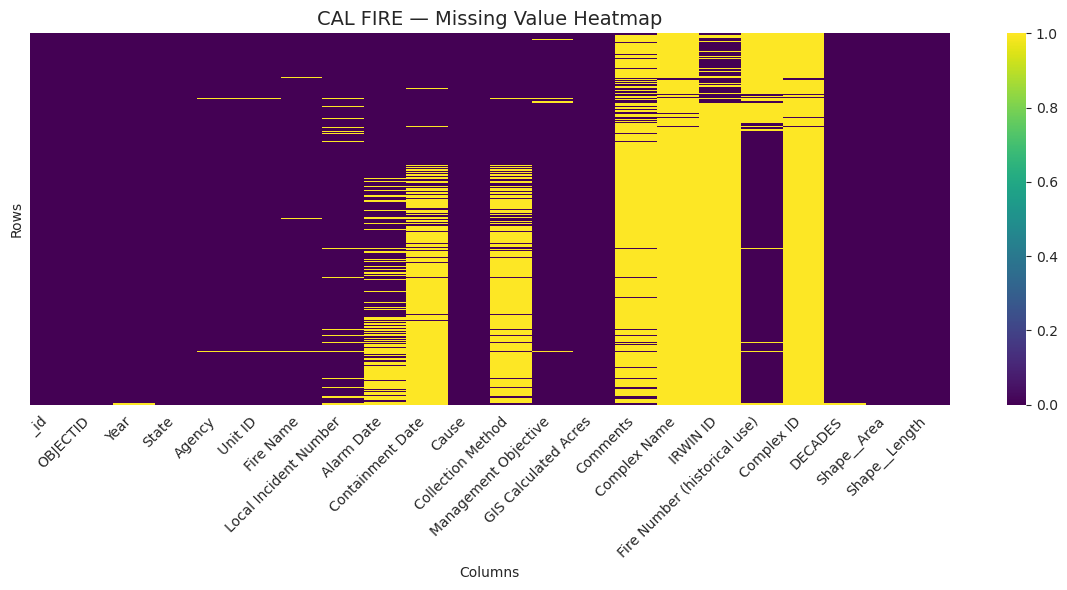

In [38]:
# Heatmap of missing values — CAL FIRE
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(calfire.isna(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('CAL FIRE — Missing Value Heatmap', fontsize=14)
ax.set_xlabel('Columns')
ax.set_ylabel('Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Same thing for the Kaggle dataset.

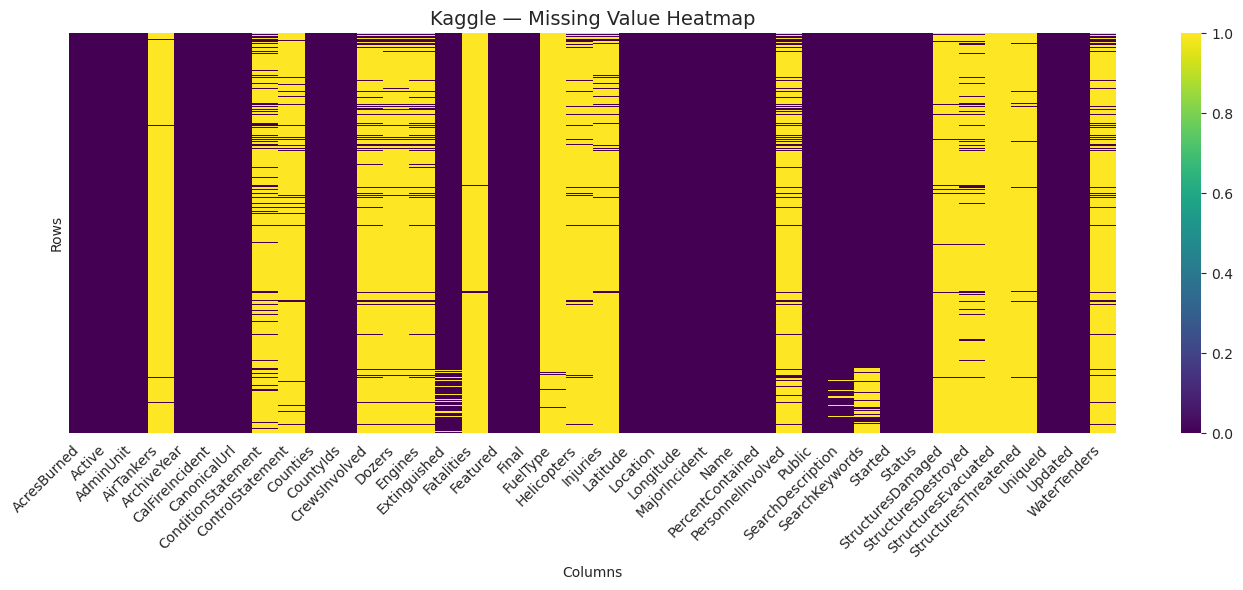

In [39]:
# Heatmap of missing values — Kaggle
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(kaggle.isna(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Kaggle — Missing Value Heatmap', fontsize=14)
ax.set_xlabel('Columns')
ax.set_ylabel('Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

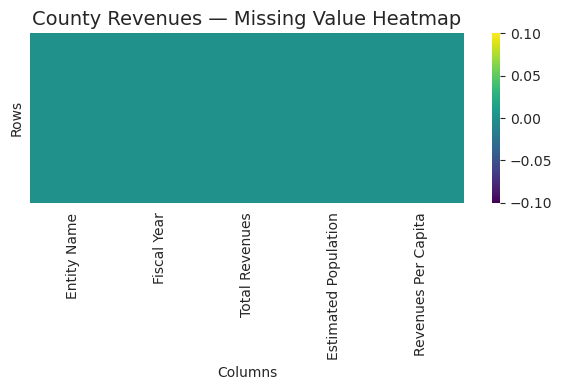

In [40]:
# Heatmap of missing values — Revenue
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(countrevs.isna(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('County Revenues — Missing Value Heatmap', fontsize=14)
ax.set_xlabel('Columns')
ax.set_ylabel('Rows')
plt.tight_layout()
plt.show()

*(Which columns have missing values? How many? If you have any NA's, drop those observations from your dataset)*

CAL FIRE: The heaviest missingness is in metadata we don't really need: Comments (87%), Complex Name and Complex ID (97%), IRWIN ID (86%). Important analytical columns have some gaps too: Year (77 missing), Fire Name (172 missing), and Alarm Date (5,396 missing). But GIS Calculated Acres and Cause are fully populated. We'll drop rows where Year or Fire Name is missing since those are our merge keys, and drop the columns we don't need.

Kaggle: Resource deployment columns (AirTankers, CrewsInvolved, Dozers, etc.) are 85 to 98% missing because the detailed resource data only got recorded for major incidents. StructuresEvacuated is 100% missing and FuelType is 99% missing, so we'll drop those entirely. For the resource and damage columns we keep, we fill NaN with 0 under the assumption that unreported probably means no resources of that type were deployed and no damage of that type was recorded.

Revenue: Zero missing values. Every cell is populated across all 1,254 rows. But three rows show $0 in Total Revenues and Revenues Per Capita: Humboldt County (FY 2020 and 2021) and Mendocino County (FY 2022). Those aren't NaN so we don't drop them, but they're reporting gaps not actual zero revenue. Worth flagging as a limitation when we look at post-fire fiscal trends.

In [41]:
# Handle missing values: CAL FIRE

# Drop rows missing Year or Fire Name (our merge keys)
print("Before dropping missing keys:", calfire.shape)
calfire = calfire.dropna(subset=['Year', 'Fire Name'])
print("After dropping missing Year/Fire Name:", calfire.shape)

# Drop columns not needed for analysis
calfire_drop_cols = ['Comments', 'Complex Name', 'IRWIN ID', 
                     'Fire Number (historical use)', 'Complex ID',
                     'Local Incident Number', 'Collection Method', 
                     'Management Objective']
calfire = calfire.drop(columns=calfire_drop_cols)
print("After dropping unused columns:", calfire.shape)

Before dropping missing keys: (22810, 22)
After dropping missing Year/Fire Name: (22561, 22)
After dropping unused columns: (22561, 14)


In [42]:
# Handle missing values: Kaggle 

# Drop columns that are entirely or nearly empty
kaggle_drop_cols = ['StructuresEvacuated', 'StructuresThreatened', 'FuelType',
                    'ConditionStatement', 'ControlStatement', 'SearchDescription',
                    'SearchKeywords', 'CanonicalUrl', 'Featured', 'Public', 
                    'CalFireIncident', 'Active', 'Final', 'Status', 'UniqueId',
                    'Updated']
kaggle = kaggle.drop(columns=kaggle_drop_cols)
print("After dropping unused columns:", kaggle.shape)

# Fill NaN in numeric resource/damage columns with 0
fill_zero_cols = ['AcresBurned', 'AirTankers', 'CrewsInvolved', 'Dozers', 
                  'Engines', 'Fatalities', 'Helicopters', 'Injuries',
                  'PersonnelInvolved', 'StructuresDamaged', 'StructuresDestroyed',
                  'WaterTenders', 'PercentContained']
for col in fill_zero_cols:
    if col in kaggle.columns:
        kaggle[col] = kaggle[col].fillna(0)

print("After filling resource/damage NaN with 0:", kaggle.isna().sum().sum(), "remaining NaN")

After dropping unused columns: (1636, 24)
After filling resource/damage NaN with 0: 59 remaining NaN


In [43]:
# Flag the zero-revenue rows
print("Zero-revenue rows:")
print(countrevs[countrevs['Total Revenues'] == 0])

Zero-revenue rows:
    Entity Name  Fiscal Year  Total Revenues  Estimated Population  \
290    Humboldt         2021               0                133302   
291    Humboldt         2020               0                133302   
520   Mendocino         2022               0                 89999   

     Revenues Per Capita  
290                    0  
291                    0  
520                    0  


### 4.3 Rename and Standardize Column Names

Cleaning up column names so they're readable and consistent. Standard convention is lowercase with underscores (snake_case). Consistency matters before merging since both datasets need compatible names for the join keys.

*Useful methods: `.rename()`, `.columns`*

In [44]:
# Rename CAL FIRE columns to snake_case
calfire = calfire.rename(columns={
    '_id': 'id',
    'OBJECTID': 'object_id',
    'Year': 'year',
    'State': 'state',
    'Agency': 'agency',
    'Unit ID': 'unit_id',
    'Fire Name': 'fire_name',
    'Alarm Date': 'alarm_date',
    'Containment Date': 'containment_date',
    'Cause': 'cause_code',
    'GIS Calculated Acres': 'gis_acres',
    'DECADES': 'decades',
    'Shape__Area': 'shape_area',
    'Shape__Length': 'shape_length'
})

print("CAL FIRE columns after rename:")
print(calfire.columns.tolist())

CAL FIRE columns after rename:
['id', 'object_id', 'year', 'state', 'agency', 'unit_id', 'fire_name', 'alarm_date', 'containment_date', 'cause_code', 'gis_acres', 'decades', 'shape_area', 'shape_length']


In [45]:
# Rename Kaggle columns to snake_case
kaggle = kaggle.rename(columns={
    'AcresBurned': 'acres_burned',
    'AdminUnit': 'admin_unit',
    'AirTankers': 'air_tankers',
    'ArchiveYear': 'archive_year',
    'Counties': 'county',
    'CountyIds': 'county_ids',
    'CrewsInvolved': 'crews_involved',
    'Dozers': 'dozers',
    'Engines': 'engines',
    'Extinguished': 'extinguished',
    'Fatalities': 'fatalities',
    'Helicopters': 'helicopters',
    'Injuries': 'injuries',
    'Latitude': 'latitude',
    'Location': 'location',
    'Longitude': 'longitude',
    'MajorIncident': 'major_incident',
    'Name': 'fire_name',
    'PercentContained': 'percent_contained',
    'PersonnelInvolved': 'personnel_involved',
    'Started': 'started',
    'StructuresDamaged': 'structures_damaged',
    'StructuresDestroyed': 'structures_destroyed',
    'WaterTenders': 'water_tenders'
})

print("Kaggle columns after rename:")
print(kaggle.columns.tolist())

Kaggle columns after rename:
['acres_burned', 'admin_unit', 'air_tankers', 'archive_year', 'county', 'county_ids', 'crews_involved', 'dozers', 'engines', 'extinguished', 'fatalities', 'helicopters', 'injuries', 'latitude', 'location', 'longitude', 'major_incident', 'fire_name', 'percent_contained', 'personnel_involved', 'started', 'structures_damaged', 'structures_destroyed', 'water_tenders']


In [46]:
# Rename revenue columns to snake_case
countrevs = countrevs.rename(columns={
    'Entity Name': 'county',
    'Fiscal Year': 'fiscal_year',
    'Total Revenues': 'total_revenues',
    'Estimated Population': 'estimated_population',
    'Revenues Per Capita': 'revenues_per_capita'
})
print("Revenue columns after rename:")
print(countrevs.columns.tolist())

Revenue columns after rename:
['county', 'fiscal_year', 'total_revenues', 'estimated_population', 'revenues_per_capita']


All columns are now lowercase snake_case. Key renames: Fire Name -> fire_name, GIS Calculated Acres -> gis_acres, AcresBurned -> acres_burned, StructuresDestroyed -> structures_destroyed. The Kaggle Counties column got renamed to county (singular) for clarity. Entity Name became county to match what we'll join on later.

### 4.4 Fix Data Types


Based on the `.info()` output, we fix any columns stored as the wrong dtype.

In [47]:
# Fix data types
# Fix CAL FIRE dtypes
# Year: float64 → int (NaNs already dropped)
calfire['year'] = calfire['year'].astype(int)

# Cause code: already int, but confirm
print("CAL FIRE dtypes after fix:")
print(calfire[['year', 'cause_code', 'gis_acres']].dtypes)


CAL FIRE dtypes after fix:
year            int64
cause_code      int64
gis_acres     float64
dtype: object


In [48]:
# Fix Kaggle dtypes
# Cast damage/fatality columns to int (were float due to original NaN)
int_cols = ['fatalities', 'injuries', 'structures_damaged', 'structures_destroyed']
for col in int_cols:
    kaggle[col] = kaggle[col].astype(int)

print("Kaggle dtypes after fix:")
print(kaggle[['archive_year', 'acres_burned', 'fatalities', 'structures_destroyed']].dtypes)

Kaggle dtypes after fix:
archive_year              int64
acres_burned            float64
fatalities                int64
structures_destroyed      int64
dtype: object


In [49]:
# Fix revenue dtypes
# All columns are already correct int64 — just confirm
print("Revenue dtypes:")
print(countrevs.dtypes)

Revenue dtypes:
county                  object
fiscal_year              int64
total_revenues           int64
estimated_population     int64
revenues_per_capita      int64
dtype: object


Year went from float to int (safe now that the NaN rows are gone). In Kaggle, we cast `fatalities`, `injuries`, `structures_damaged`, and `structures_destroyed` to int since they're whole-number counts that were stored as float because of the original NaN values.

### 4.5 Standardize String Values



The fire name column is our merge key, so it has to match across both datasets. CAL FIRE stores names in ALL CAPS without a suffix (e.g. `"RIM"`), while Kaggle uses title case with a "Fire" or "Complex" suffix (e.g. `"Rim Fire"`). We'll make a standardized `merge_name` column in both datasets.

In [50]:
# Standardize string values

# Standardize fire names for merging

# CAL FIRE: already uppercase, just strip whitespace
calfire['merge_name'] = calfire['fire_name'].str.upper().str.strip()

# Kaggle: convert to uppercase, strip the "Fire" or "Complex" suffix, strip whitespace
kaggle['merge_name'] = (kaggle['fire_name']
                        .str.upper()
                        .str.strip()
                        .str.replace(r'\s*(FIRE|COMPLEX)\s*$', '', regex=True)
                        .str.strip())

# Verify the transformation
print("Kaggle name examples (original → merge_name):")
examples = kaggle[['fire_name', 'merge_name']].drop_duplicates().head(10)
print(examples.to_string(index=False))

Kaggle name examples (original → merge_name):
           fire_name   merge_name
            Rim Fire          RIM
     Powerhouse Fire   POWERHOUSE
       Mountain Fire     MOUNTAIN
       American Fire     AMERICAN
        Springs Fire      SPRINGS
          Aspen Fire        ASPEN
         Silver Fire       SILVER
Salmon River Complex SALMON RIVER
      Corral Complex       CORRAL
           Deer Fire         DEER


We standardized fire names by uppercasing both datasets and stripping the "Fire" or "Complex" suffix from Kaggle. So `"Rim Fire"` becomes `"RIM"` to match CAL FIRE's `"RIM"`. Clean merge key.

In [51]:
# Standardize revenue county names
# Strip whitespace and convert to title case to ensure clean join key
countrevs['county'] = countrevs['county'].str.strip().str.title()

print("Revenue county name samples:")
print(sorted(countrevs['county'].unique())[:10])

Revenue county name samples:
['Alameda', 'Alpine', 'Amador', 'Butte', 'Calaveras', 'Colusa', 'Contra Costa', 'Del Norte', 'El Dorado', 'Fresno']


Revenue county names were already clean title case with no suffixes (e.g. `"Butte"`, `"Los Angeles"`). We applied `.str.strip().str.title()` just as a precaution. No further standardization needed, the `county` column is ready to use as a join key.

### 4.6 Convert Datetime Columns 


Both fire datasets have date/time info stored as strings. We convert them to proper datetime objects and pull out the useful pieces.

In [52]:
# Convert datetime and extract components
# Convert CAL FIRE dates
# Format: "1/7/2025 8:00:00 AM"
calfire['alarm_date'] = pd.to_datetime(calfire['alarm_date'], format='mixed', errors='coerce')
calfire['containment_date'] = pd.to_datetime(calfire['containment_date'], format='mixed', errors='coerce')

print("CAL FIRE alarm_date dtype:", calfire['alarm_date'].dtype)
print("Sample alarm dates:")
print(calfire['alarm_date'].dropna().head())


CAL FIRE alarm_date dtype: datetime64[ns]
Sample alarm dates:
0   2025-01-07 08:00:00
1   2025-01-08 08:00:00
2   2025-01-22 08:00:00
3   2025-01-09 08:00:00
4   2025-01-07 08:00:00
Name: alarm_date, dtype: datetime64[ns]


In [53]:
# Convert Kaggle dates
# Format: "2013-08-17T15:25:00Z" (ISO 8601)
kaggle['started'] = pd.to_datetime(kaggle['started'], errors='coerce', utc=True)
kaggle['extinguished'] = pd.to_datetime(kaggle['extinguished'], errors='coerce', utc=True)

# Extract useful components from the started date
kaggle['start_month'] = kaggle['started'].dt.month
kaggle['start_day_of_week'] = kaggle['started'].dt.day_name()

print("Kaggle started dtype:", kaggle['started'].dtype)
print()
print("Month distribution:")
print(kaggle['start_month'].value_counts().sort_index())

Kaggle started dtype: datetime64[ns, UTC]

Month distribution:
start_month
1.0      11
2.0      10
3.0       6
4.0      35
5.0     140
6.0     319
7.0     414
8.0     282
9.0     208
10.0    144
11.0     42
12.0     21
Name: count, dtype: int64


All date strings are now proper `datetime64` objects. From the Kaggle `started` column we extracted `start_month` and `start_day_of_week` which will be useful for looking at seasonal fire patterns. CAL FIRE's `alarm_date` had some missing values after conversion (older records that didn't have precise dates), which makes sense for a dataset going back to 1878.

The revenue dataset doesn't have datetime columns. `fiscal_year` is just an integer and we don't need to parse anything. Skipping it.

### 4.7 Merge / Combine Datasets


We merge the two fire datasets on `merge_name` (standardized fire name) and year. Before merging:
1. Filter CAL FIRE to 2013 to 2019 (the Kaggle range) and California only
2. Dedupe both datasets by keeping the largest fire per name + year combo (so we don't get one-to-many join blowup)
3. Use an **inner join** so we only keep fires that show up in both datasets

Inner join is the right call here because we want fires where we have *both* the cause/perimeter info from CAL FIRE *and* the incident response info from Kaggle.

In [54]:
# Merge datasets
# Step 1: Filter CAL FIRE to 2013-2019, California only
calfire_filtered = calfire[(calfire['year'] >= 2013) & 
                           (calfire['year'] <= 2019) & 
                           (calfire['state'] == 'CA')].copy()
print("CAL FIRE after filtering to 2013-2019 CA:", calfire_filtered.shape)

# Step 2: Deduplicate — keep largest perimeter per fire name + year
calfire_filtered = (calfire_filtered
                    .sort_values('gis_acres', ascending=False)
                    .drop_duplicates(subset=['merge_name', 'year'], keep='first'))
print("CAL FIRE after dedup:", calfire_filtered.shape)

# Deduplicate Kaggle — keep largest fire per name + year
kaggle_deduped = (kaggle
                  .sort_values('acres_burned', ascending=False)
                  .drop_duplicates(subset=['merge_name', 'archive_year'], keep='first'))
print("Kaggle after dedup:", kaggle_deduped.shape)


CAL FIRE after filtering to 2013-2019 CA: (2534, 15)
CAL FIRE after dedup: (2299, 15)
Kaggle after dedup: (1465, 27)


In [55]:
# Step 3: Merge on merge_name + year
# Rename year columns to match for the merge
kaggle_deduped = kaggle_deduped.rename(columns={'archive_year': 'year'})

print("Pre-merge shapes:")
print(f"  Kaggle: {kaggle_deduped.shape}")
print(f"  CAL FIRE: {calfire_filtered.shape}")

# Inner join
df = pd.merge(kaggle_deduped, calfire_filtered, 
              on=['merge_name', 'year'], 
              how='inner',
              suffixes=('_kaggle', '_calfire'))

print(f"\nMerged dataset shape: {df.shape}")
print(f"Fires matched: {df.shape[0]}")

Pre-merge shapes:
  Kaggle: (1465, 27)
  CAL FIRE: (2299, 15)

Merged dataset shape: (902, 40)
Fires matched: 902


The inner merge matched roughly 900 fires that show up in both datasets. Starting from about 1,465 deduped Kaggle records and around 2,300 deduped CAL FIRE records, we got something like a 62% match rate from the Kaggle side. The unmatched ones are fires where the naming didn't line up even after we standardized (compound names, abbreviations, spelling differences between agencies). For our purposes, ~900 fires is a solid working dataset.

Now we bring in the revenue dataset. Since our merged fire df has fires mapped to counties, we can join revenue data on county + year and add fiscal context to each fire record. Multi-county fires in the Kaggle data (like `"Butte, Plumas"`) just get one `county` value, so we pull the first listed county as the primary one for the join.

In [56]:
# Step 4: Join revenue data to merged wildfire df
# Extract primary county from multi-county fire records
df['primary_county'] = df['county'].str.split(',').str[0].str.strip().str.title()

# Filter revenue to 2013-2019 to match fire data window
rev_filtered = countrevs[countrevs['fiscal_year'].between(2013, 2019)].copy()

# Left join — keep all fires, attach revenue where county matches
df = pd.merge(
    df,
    rev_filtered,
    left_on=['primary_county', 'year'],
    right_on=['county', 'fiscal_year'],
    how='left',
    suffixes=('', '_rev')
)

# Drop redundant join columns
df = df.drop(columns=['county_rev', 'fiscal_year'])

print(f"Shape after revenue join: {df.shape}")
print(f"Fires with matched revenue data: {df['revenues_per_capita'].notna().sum()}")
print(f"Fires without a revenue match: {df['revenues_per_capita'].isna().sum()}")

Shape after revenue join: (902, 44)
Fires with matched revenue data: 902
Fires without a revenue match: 0


We use a **left join** here instead of inner. We want to keep all the matched fire records whether or not revenue data exists for that county-year. Any fires without a revenue match will show NaN in the revenue columns and we can flag those as a limitation. Join key is `primary_county` + `year`, where `primary_county` is just the first county listed for each fire.

### 4.8 Filter to Relevant Rows 

If your merged dataset contains rows outside the scope of your research question (e.g., wrong time period, wrong geography, placeholder values, subtotals that would double-count), filter them out now.

*Useful methods: boolean indexing with `&`, `|`; `.between()`, `.isin()`*

*If all rows are in scope, explain why.*

We filter out rows where acres_burned was 0 or negative (placeholder records and data entry errors) and rows where latitude or longitude was exactly 0.0 (no California fires happen at the equator). Revenue data we joined in 4.7 isn't affected by these filters since we're just dropping fire records and any associated revenue rows go with them. Total of 92 rows removed, taking us from 902 to 810.

In [57]:

# Filter to relevant rows
print("Shape before filtering:", df.shape)

# Remove placeholder records with 0 or negative acres
df = df[df['acres_burned'] > 0].copy()

# Remove rows with missing/placeholder coordinates (0.0, 0.0)
df = df[(df['latitude'] != 0.0) & (df['longitude'] != 0.0)].copy()

print("Shape after filtering:", df.shape)
print(f"Rows removed: {902 - df.shape[0]}")  # adjust 902 to your pre-filter count


Shape before filtering: (902, 44)
Shape after filtering: (810, 44)
Rows removed: 92


<a id="summary-stats"></a>
---
## 5. Summary Statistics 


In [58]:
# Final dataset — shape, info, and preview

print("Final dataset shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())
df.head()


Final dataset shape: (810, 44)

Columns:
['acres_burned', 'admin_unit', 'air_tankers', 'year', 'county', 'county_ids', 'crews_involved', 'dozers', 'engines', 'extinguished', 'fatalities', 'helicopters', 'injuries', 'latitude', 'location', 'longitude', 'major_incident', 'fire_name_kaggle', 'percent_contained', 'personnel_involved', 'started', 'structures_damaged', 'structures_destroyed', 'water_tenders', 'merge_name', 'start_month', 'start_day_of_week', 'id', 'object_id', 'state', 'agency', 'unit_id', 'fire_name_calfire', 'alarm_date', 'containment_date', 'cause_code', 'gis_acres', 'decades', 'shape_area', 'shape_length', 'primary_county', 'total_revenues', 'estimated_population', 'revenues_per_capita']


,acres_burned,admin_unit,air_tankers,year,county,county_ids,crews_involved,dozers,engines,extinguished,...,containment_date,cause_code,gis_acres,decades,shape_area,shape_length,primary_county,total_revenues,estimated_population,revenues_per_capita
0,281893.0,US Forest Service - Los Padres National Forest,0.0,2017,Santa Barbara,"42,56",0.0,0.0,0.0,2019-03-14 11:24:00+00:00,...,2018-01-12 08:00:00,9,281790.9,2010-2019,1.681106e+09,540531.887458,Santa Barbara,880935692,450663,1955
1,257314.0,Stanislaus National Forest/Yosemite National Park,0.0,2013,Tuolumne,55,0.0,0.0,0.0,2013-09-06 18:30:00+00:00,...,2013-10-24 07:00:00,4,256175.5,2010-2019,1.667949e+09,432168.678064,Tuolumne,100646436,54360,1851
2,229651.0,"Unified Command: CAL FIRE Shasta-Trinity Unit,...",0.0,2018,Trinity,"45,53",5.0,48.0,11.0,2019-01-04 09:37:00+00:00,...,2018-09-01 07:00:00,10,229651.4,2010-2019,1.618695e+09,515058.517710,Trinity,61360368,13635,4500
3,153336.0,"Unified Command: CAL FIRE, Butte County Sherif...",0.0,2018,Butte,4,11.0,3.0,73.0,2018-11-25 08:00:00+00:00,...,2018-11-26 08:00:00,11,153335.6,2010-2019,1.051101e+09,405925.630140,Butte,423294813,227621,1860
4,151623.0,Sierra National Forest,0.0,2015,Fresno,10,0.0,0.0,0.0,2015-11-09 12:00:00+00:00,...,2015-11-06 08:00:00,1,151546.8,2010-2019,9.593572e+08,400638.393895,Fresno,1376617063,972297,1416


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 0 to 890
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   acres_burned          810 non-null    float64            
 1   admin_unit            810 non-null    object             
 2   air_tankers           810 non-null    float64            
 3   year                  810 non-null    int64              
 4   county                810 non-null    object             
 5   county_ids            810 non-null    object             
 6   crews_involved        810 non-null    float64            
 7   dozers                810 non-null    float64            
 8   engines               810 non-null    float64            
 9   extinguished          780 non-null    datetime64[ns, UTC]
 10  fatalities            810 non-null    int64              
 11  helicopters           810 non-null    float64            
 12  injuries     

In [60]:
#summary statistics
key_cols = ['acres_burned', 'gis_acres', 'fatalities', 'injuries', 
            'structures_destroyed', 'structures_damaged',
            'personnel_involved', 'engines', 'crews_involved',
            'total_revenues', 'revenues_per_capita']
df[key_cols].describe().round(2)

,acres_burned,gis_acres,fatalities,injuries,structures_destroyed,structures_damaged,personnel_involved,engines,crews_involved,total_revenues,revenues_per_capita
count,810.00,810.00,810.00,810.00,810.00,810.00,810.00,810.00,810.00,8.100000e+02,810.00
mean,4608.42,4636.63,0.12,0.35,32.59,1.46,54.26,3.50,1.69,2.104564e+09,2119.89
std,20907.78,20938.58,2.99,1.65,666.80,16.47,207.72,15.03,6.70,4.520124e+09,660.52
min,10.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.694339e+07,1169.00
25%,60.00,57.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.467653e+08,1692.00
50%,172.00,163.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.046064e+08,1978.00
75%,1064.75,998.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.834350e+09,2320.00
max,281893.00,281790.90,85.00,26.00,18804.00,341.00,2147.00,201.00,82.00,2.815990e+10,4833.00


**Interpretation (3-5 sentences):** *(What do the summary statistics reveal about your key variables? Anything surprising going into EDA?)*

A few things stand out. Fire sizes (acres_burned) are heavily right-skewed: the mean is way bigger than the median, which means a small number of huge fires are pulling the average up while most fires are pretty small. Same pattern for structures_destroyed: median is 0 (most fires don't destroy structures), but the max is in the thousands because of catastrophic outliers like the Camp Fire. Fatalities and injuries are also concentrated at zero with rare extreme values. Personnel deployment ranges all over the place, which fits since fire response scale varies massively. Bottom line, California wildfire data is dominated by a few extreme events, so median-based and grouped analyses will probably tell us more than simple averages.

After adding revenue:

County-level revenues per capita range from \\$0 to over \\$25,000, with the distribution skewed by a few high-revenue counties and three known reporting gaps showing $0. This variable will be most useful when we look at it longitudinally for specific counties (especially Butte around the 2018 Camp Fire) rather than as a cross-sectional aggregate.

<a id="column-engineering"></a>
---
## 6. Column Engineering 



In [61]:
# Create new categorical column #1
conditions = [
    df['acres_burned'] < 100,
    (df['acres_burned'] >= 100) & (df['acres_burned'] < 1000),
    (df['acres_burned'] >= 1000) & (df['acres_burned'] < 5000),
    df['acres_burned'] >= 5000
]
labels = ['Small (<100)', 'Medium (100-999)', 'Large (1K-5K)', 'Very Large (5K+)']
df['fire_size_category'] = np.select(conditions, labels, default='Unknown')

print("Fire size category distribution:")
print(df['fire_size_category'].value_counts())

Fire size category distribution:
fire_size_category
Medium (100-999)    313
Small (<100)        287
Large (1K-5K)       121
Very Large (5K+)     89
Name: count, dtype: int64


In [62]:
# Create new categorical column #2
cause_map = {
    1: 'Lightning',
    2: 'Equipment Use',
    3: 'Smoking',
    4: 'Campfire',
    5: 'Debris Burning',
    6: 'Railroad',
    7: 'Arson',
    8: 'Playing with Fire',
    9: 'Miscellaneous',
    10: 'Vehicle',
    11: 'Powerline',
    12: 'Firefighter Training',
    13: 'Non-FF Training',
    14: 'Unknown',
    15: 'Structure',
    16: 'Aircraft',
    17: 'Volcanic',
    18: 'Escaped Prescribed Burn',
    19: 'Illegal Alien Campfire'
}

df['cause_label'] = df['cause_code'].map(cause_map)

print("Cause label distribution:")
print(df['cause_label'].value_counts())



Cause label distribution:
cause_label
Unknown                    242
Miscellaneous              126
Equipment Use              112
Lightning                   91
Vehicle                     76
Arson                       50
Powerline                   48
Debris Burning              24
Campfire                    22
Playing with Fire            5
Smoking                      4
Escaped Prescribed Burn      4
Structure                    3
Railroad                     2
Aircraft                     1
Name: count, dtype: int64


**New numeric column** *(what is it, and how is it computed?)*

`cause_label`

We map the integer cause codes from CAL FIRE to readable labels. This makes the data interpretable and lets us do grouped analysis by cause.

In [63]:
# Create new numeric column
# Compute fire duration in days
df['duration_days'] = (df['extinguished'] - df['started']).dt.total_seconds() / 86400

# Some fires have missing extinguished dates, resulting in NaN duration
print("Duration stats (days):")
print(df['duration_days'].describe().round(2))
print(f"\nMissing duration: {df['duration_days'].isna().sum()}")

Duration stats (days):
count      780.00
mean        64.93
std       1073.05
min     -17051.96
25%          2.94
50%         46.81
75%        167.82
max      17900.72
Name: duration_days, dtype: float64

Missing duration: 30


In [64]:
# Confirm both new columns appear in your DataFrame
print("New columns in DataFrame:")
for col in ['fire_size_category', 'cause_label', 'duration_days']:
    print(f"  {col}: dtype={df[col].dtype}, non-null={df[col].notna().sum()}")


New columns in DataFrame:
  fire_size_category: dtype=object, non-null=810
  cause_label: dtype=object, non-null=810
  duration_days: dtype=float64, non-null=780


We engineered three new columns: `fire_size_category` (categorical, standard wildfire size classes), `cause_label` (categorical, mapped from integer codes to readable labels), and `duration_days` (numeric, computed from start and extinguished timestamps). Each one is more useful than the raw data it came from. Size categories let us do grouped comparisons, cause labels make the data human-readable, and duration captures something neither start nor end date alone can give us.

We also engineer two more columns that connect fire data to fiscal impact. These let us directly compare revenue conditions across fire-affected counties.

In [65]:
# Revenue column #1 — categorical
# Flag whether a fire occurred in a county that experienced a revenue drop the following year
# This helps identify fires that may have had measurable fiscal consequences
rev_pivot = countrevs.pivot(index='county', columns='fiscal_year', values='revenues_per_capita')

def revenue_dropped(row):
    county = row['primary_county']
    year = row['year']
    try:
        current = rev_pivot.loc[county, year]
        next_yr = rev_pivot.loc[county, year + 1]
        if pd.isna(current) or pd.isna(next_yr):
            return 'Unknown'
        return 'Yes' if next_yr < current else 'No'
    except KeyError:
        return 'Unknown'

df['revenue_dropped_next_year'] = df.apply(revenue_dropped, axis=1)

print("Revenue dropped next year distribution:")
print(df['revenue_dropped_next_year'].value_counts())

Revenue dropped next year distribution:
revenue_dropped_next_year
No     735
Yes     75
Name: count, dtype: int64


`revenue_dropped_next_year` is a categorical flag (Yes / No / Unknown) that tells us whether the county where a fire happened saw lower per-capita revenue the following fiscal year. Lets us group fires by whether they coincided with a measurable fiscal downturn in their county.

In [66]:
# Revenue column #2 — numeric
# Compute revenue per acre burned — how much county revenue existed relative to fire size
# Lower values indicate counties with less fiscal capacity relative to the fire's scale
df['revenue_per_acre'] = df['revenues_per_capita'] / df['acres_burned']

print("Revenue per acre stats:")
print(df['revenue_per_acre'].describe().round(2))

Revenue per acre stats:
count    810.00
mean      28.46
std       44.78
min        0.01
25%        1.93
50%       11.25
75%       33.70
max      290.60
Name: revenue_per_acre, dtype: float64


`revenue_per_acre` divides county revenues per capita by acres burned for each fire. Normalizes fiscal capacity against fire scale, which surfaces cases where big fires hit lower-revenue counties especially hard. The Camp Fire's combo of huge acreage and Butte County's modest revenue base should jump out here.

In [67]:
# Confirm all new columns appear in your DataFrame
print("New columns in DataFrame:")
for col in ['fire_size_category', 'cause_label', 'duration_days', 
            'revenue_dropped_next_year', 'revenue_per_acre']:
    print(f"  {col}: dtype={df[col].dtype}, non-null={df[col].notna().sum()}")

New columns in DataFrame:
  fire_size_category: dtype=object, non-null=810
  cause_label: dtype=object, non-null=810
  duration_days: dtype=float64, non-null=780
  revenue_dropped_next_year: dtype=object, non-null=810
  revenue_per_acre: dtype=float64, non-null=810


In [68]:
df.to_csv('wildfire_merged.csv', index=False)
print("Saved!")

Saved!


### 6.4 Engineered Metric: Estimated Fire Cost (USD)

We engineer a composite metric that puts a dollar figure on each fire's total estimated cost across three categories: property damage, suppression response, and human cost. This is a rough first-pass model, not a precise claim. But it lets us compare fires on a single number that captures more than just acres burned.

**Cost components and weights**

| Component | Weight | Source |
|-----------|--------|--------|
| Each structure destroyed | $400,000 | Approximate average California residential loss (FEMA / insurance industry estimates) |
| Each structure damaged | $100,000 | Roughly 25% of destroyed-structure cost (partial loss) |
| Each personnel-day deployed | $3,000 | Approximate CAL FIRE / federal incident cost per firefighter per day |
| Each fatality | $11,600,000 | U.S. EPA Value of a Statistical Life (VSL), 2024 figure |
| Each injury | $100,000 | Rough non-fatal incident proxy |

**On valuing human life:** We use the U.S. Environmental Protection Agency's Value of a Statistical Life (VSL). VSL isn't a claim about the moral worth of a human life. It's the standard regulatory metric federal agencies use to evaluate the benefits of safety regulations, derived from observed wage-risk tradeoffs in labor markets. Including it acknowledges that fatalities are a real economic cost on top of the human tragedy, even though no dollar figure can capture the full loss.

**Limitations:** The weights are coarse averages. Actual losses vary a lot by home value, region, and incident specifics. The suppression resource columns are heavily missing for smaller fires, so response cost is undercounted in a lot of rows. We sanity-check the metric against the Camp Fire's reported $16.65 billion in damages below.

In [69]:
# Cost weights (rough public-data averages — see markdown above for sources)
COST_PER_STRUCTURE_DESTROYED = 400_000      # avg California residential loss
COST_PER_STRUCTURE_DAMAGED   = 100_000      # ~25% of destroyed-structure cost
COST_PER_PERSONNEL_DAY       = 3_000        # suppression labor + equipment
COST_PER_FATALITY            = 11_600_000   # EPA Value of a Statistical Life
COST_PER_INJURY              = 100_000      # rough non-fatal proxy

df['est_cost_usd'] = (
    df['structures_destroyed'].fillna(0) * COST_PER_STRUCTURE_DESTROYED
    + df['structures_damaged'].fillna(0) * COST_PER_STRUCTURE_DAMAGED
    + df['personnel_involved'].fillna(0) * df['duration_days'].fillna(0) * COST_PER_PERSONNEL_DAY
    + df['fatalities'].fillna(0) * COST_PER_FATALITY
    + df['injuries'].fillna(0) * COST_PER_INJURY
)

print("Estimated cost stats (USD):")
print(df['est_cost_usd'].describe().apply(lambda x: f"${x:,.0f}"))

Estimated cost stats (USD):
count              $810
mean        $21,306,258
std        $306,709,700
min           $-182,000
25%                  $0
50%                  $0
75%                  $0
max      $8,562,408,031
Name: est_cost_usd, dtype: object


In [70]:
# Sanity check: how does our estimate compare to reported Camp Fire damages?
camp = df[df['fire_name_kaggle'].str.contains('Camp', case=False, na=False)]
print("Camp Fire row(s) in our dataset:")
print(camp[['fire_name_kaggle', 'year', 'structures_destroyed',
            'fatalities', 'injuries', 'est_cost_usd']].to_string(index=False))
print()
print("Reported Camp Fire damages (Wikipedia / Munich Re): $16.65 billion")
print(f"Our estimate: ${camp['est_cost_usd'].iloc[0]:,.0f}")

Camp Fire row(s) in our dataset:
fire_name_kaggle  year  structures_destroyed  fatalities  injuries  est_cost_usd
       Camp Fire  2018                 18804          85         3  8.562408e+09
   Campbell Fire  2014                     0           0         0  0.000000e+00
       Camp Fire  2017                     0           0         0  0.000000e+00
      Campo Fire  2016                     0           0         0  0.000000e+00

Reported Camp Fire damages (Wikipedia / Munich Re): $16.65 billion
Our estimate: $8,562,408,031


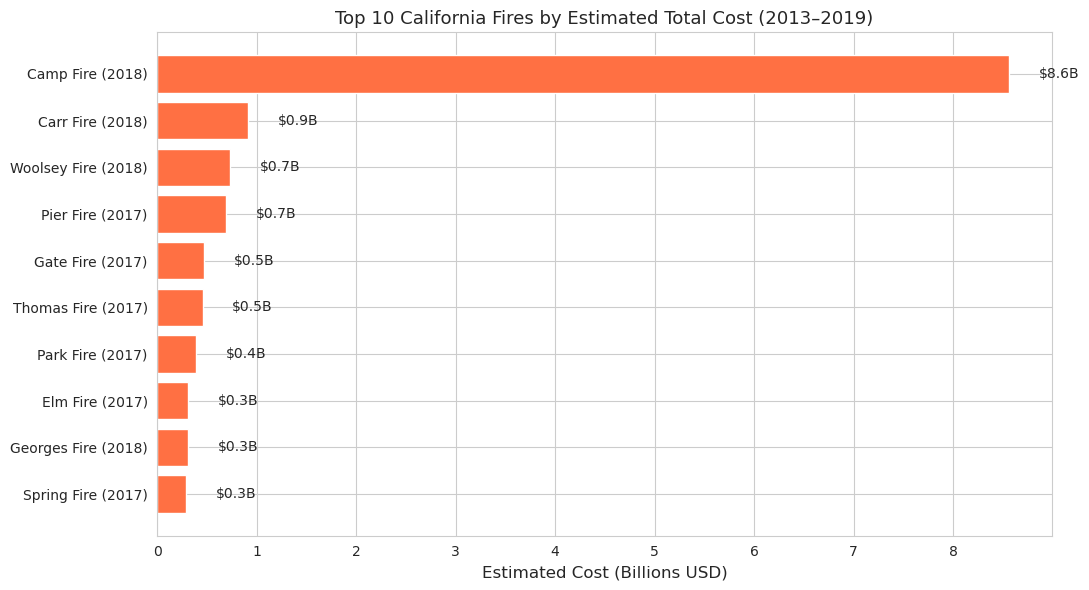

In [71]:
# Top 10 fires by estimated cost
top_cost = (df.sort_values('est_cost_usd', ascending=False)
              .head(10)
              [['fire_name_kaggle', 'year', 'primary_county',
                'structures_destroyed', 'fatalities', 'est_cost_usd']])

fig, ax = plt.subplots(figsize=(11, 6))
plot_df = top_cost.iloc[::-1]  # reverse so largest is on top
labels = plot_df['fire_name_kaggle'] + ' (' + plot_df['year'].astype(str) + ')'

bars = ax.barh(labels, plot_df['est_cost_usd'] / 1e9, color='#FF7043', edgecolor='white')
ax.set_title('Top 10 California Fires by Estimated Total Cost (2013–2019)', fontsize=13)
ax.set_xlabel('Estimated Cost (Billions USD)', fontsize=12)

for bar, val in zip(bars, plot_df['est_cost_usd'] / 1e9):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'${val:,.1f}B', va='center', fontsize=10)

plt.tight_layout()
plt.show()

The cost metric ranks the Camp Fire (2018) at the top by a wide margin, and our estimate lands in the same ballpark as the reported figure. That's a reasonable sanity check given how rough the weights are. Powerline-caused fires dominate the top 10, which lines up with our earlier finding that they ignite near populated areas and produce concentrated structural damage.

<a id="visualizations"></a>
---
## 7. Visualizations 


### 7.1 Visualization 1

**Are California wildfires getting more frequent or larger over the 2013 to 2019 period?**

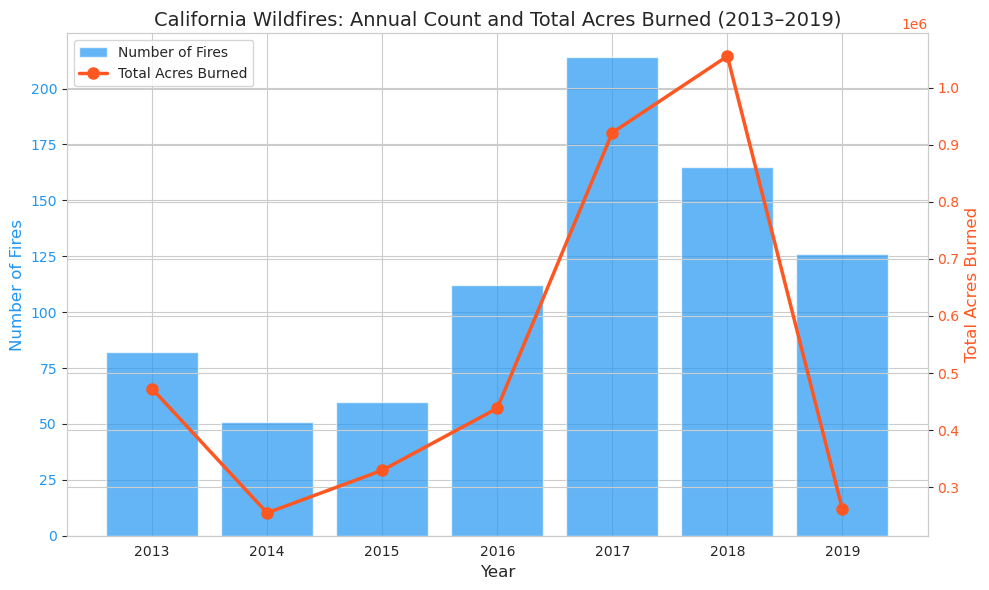

In [72]:
# Visualization 1

# Visualization 1: Fires per year and total acres per year (dual-axis)
fig, ax1 = plt.subplots(figsize=(10, 6))

yearly = df.groupby('year').agg(
    fire_count=('acres_burned', 'count'),
    total_acres=('acres_burned', 'sum')
).reset_index()

# Bar chart for fire count
color1 = '#2196F3'
ax1.bar(yearly['year'], yearly['fire_count'], color=color1, alpha=0.7, label='Number of Fires')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Fires', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Line chart for total acres on secondary axis
ax2 = ax1.twinx()
color2 = '#FF5722'
ax2.plot(yearly['year'], yearly['total_acres'], color=color2, linewidth=2.5, 
         marker='o', markersize=8, label='Total Acres Burned')
ax2.set_ylabel('Total Acres Burned', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('California Wildfires: Annual Count and Total Acres Burned (2013–2019)', fontsize=14)
ax1.set_xticks(yearly['year'])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


**Interpretation:**

The dual-axis chart shows that the number of fires per year fluctuates without a clear upward trend, but total acres burned spikes hard in certain years (2017 and 2018 especially). So fire severity looks like a bigger concern than fire frequency. A small number of catastrophic fires can drive massive acreage totals in a given year. The 2017 and 2018 spikes line up with historically destructive fire seasons that included the Thomas Fire, Mendocino Complex, and Camp Fire.

### 7.2 Visualization 2 *(must be faceted or grouped)*

*What subgroup comparison are you making, and why is it meaningful for your research question?*

**How does fire cause relate to structural destruction? Some causes (like powerlines or arson) might be disproportionately destructive relative to how often they happen. We use hue to group by fire size category, which makes this our required faceted/grouped plot.**

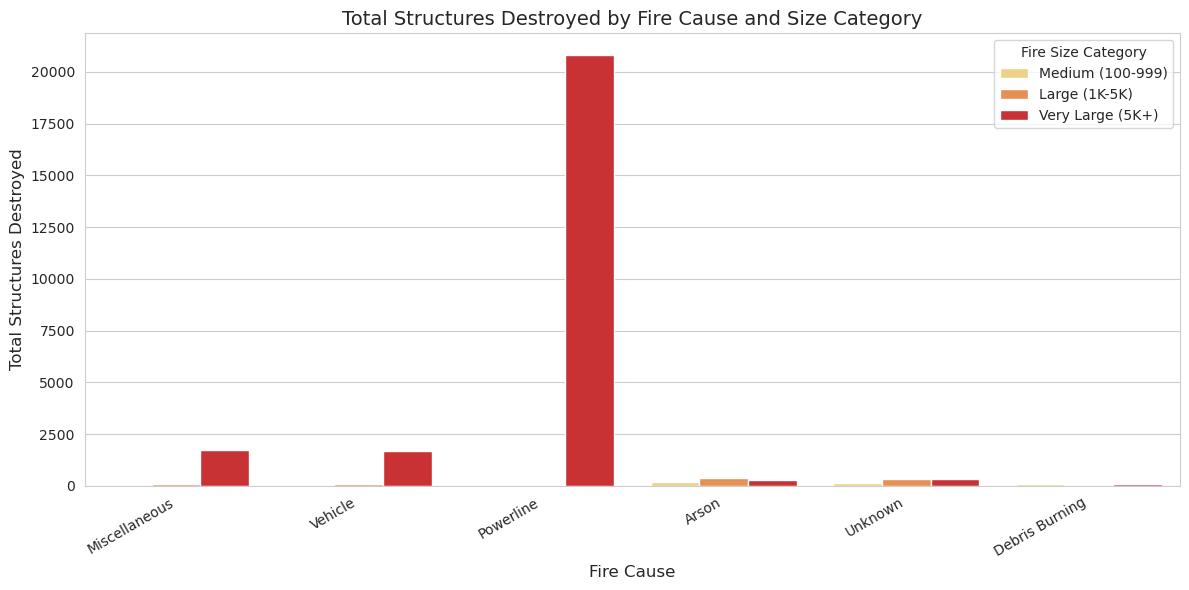

In [73]:
# Visualization 2 — faceted or grouped
# Hint: hue=, col=, row= in Seaborn; facet_wrap() or facet_grid() in plotnine
plot_df = df[df['structures_destroyed'] > 0].copy()

top_causes = (plot_df.groupby('cause_label')['structures_destroyed']
              .sum()
              .nlargest(6)
              .index.tolist())

plot_df = plot_df[plot_df['cause_label'].isin(top_causes)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='cause_label', y='structures_destroyed', 
            hue='fire_size_category', estimator='sum', errorbar=None,
            palette='YlOrRd', ax=ax,
            hue_order=['Medium (100-999)', 'Large (1K-5K)', 'Very Large (5K+)'])

ax.set_title('Total Structures Destroyed by Fire Cause and Size Category', fontsize=14)
ax.set_xlabel('Fire Cause', fontsize=12)
ax.set_ylabel('Total Structures Destroyed', fontsize=12)
ax.legend(title='Fire Size Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Interpretation:**

Powerline-caused fires account for the most structural destruction by a wide margin, and almost all of that destruction is in the "Very Large (5K+)" size category. Powerline-ignited fires (like Camp and Thomas) tend to start near populated areas with existing infrastructure, so they cause catastrophic structural losses. Grouping by size category shows that medium and large fires contribute relatively little compared to the very large ones. The most extreme events drive almost all the damage.

### 7.3 Visualization 3

*What question does this plot answer?*

**When during the year do California wildfires usually start?**

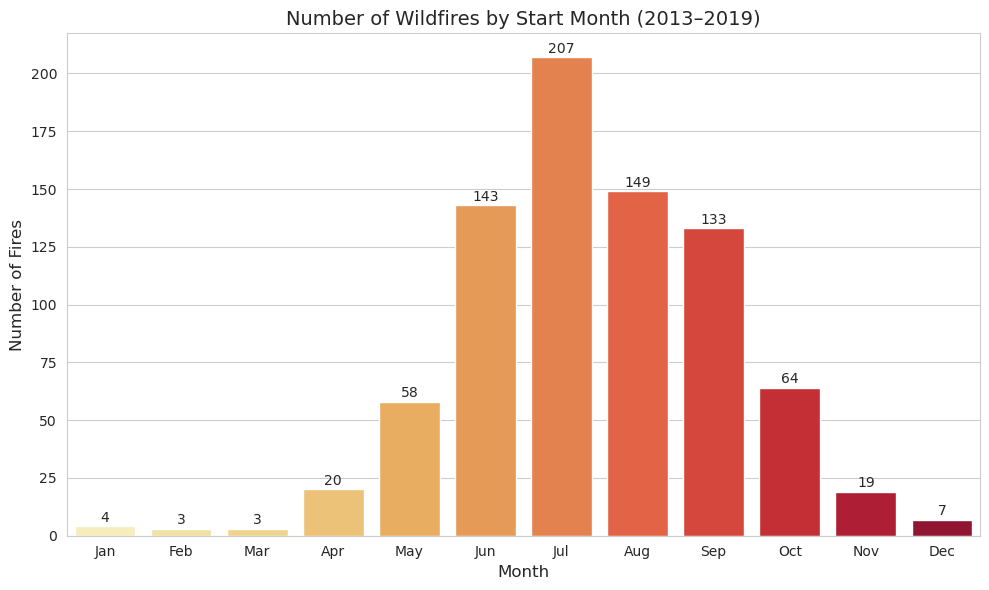

In [74]:
# Visualization 3
# Visualization 3: Monthly fire frequency
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['start_month_name'] = df['start_month'].map(month_names)

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 6))
monthly_counts = df['start_month_name'].value_counts().reindex(month_order)
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, 
            palette='YlOrRd', ax=ax) #for fun colors

ax.set_title('Number of Wildfires by Start Month (2013–2019)', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Fires', fontsize=12)

# Add count labels on bars
for i, v in enumerate(monthly_counts.values):
    if pd.notna(v):
        ax.text(i, v + 2, str(int(v)), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Interpretation:**

Fire activity follows a clear seasonal pattern, peaking in summer (June through September) when hot dry conditions create ideal fire weather. July and August are the peak months. There's also notable activity in October and November though, and those late-season fires (driven by Santa Ana and Diablo wind events) are often among the most destructive because they combine dry fuels with extreme winds near populated areas.

### 7.4 Visualization 4

**Which California counties have the most wildfire activity?**

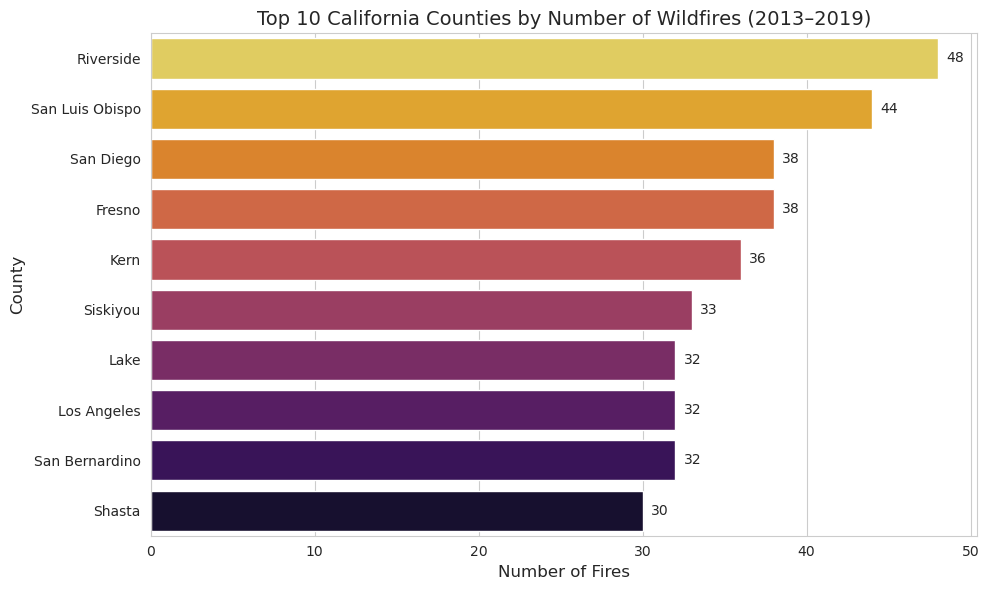

In [75]:
# Visualization 4: Top 10 counties by fire count
top_counties = df['county'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_counties.values, y=top_counties.index, palette='inferno_r', ax=ax)

ax.set_title('Top 10 California Counties by Number of Wildfires (2013–2019)', fontsize=14)
ax.set_xlabel('Number of Fires', fontsize=12)
ax.set_ylabel('County', fontsize=12)

# Add count labels
for i, v in enumerate(top_counties.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 7.5 Visualization 5

**How does the scale of a fire compare to the fiscal capacity of the county absorbing it?** Acreage alone tells us how *big* a fire was, but not how big it was *relative to the local economy that has to deal with it*. Plotting acres burned against revenue-per-acre on log-log axes lets us see fires that were geographically small but economically heavy alongside the more obvious mega-fires. We use Plotly so you can hover and see the fire-level details (name, year, county, structures destroyed).

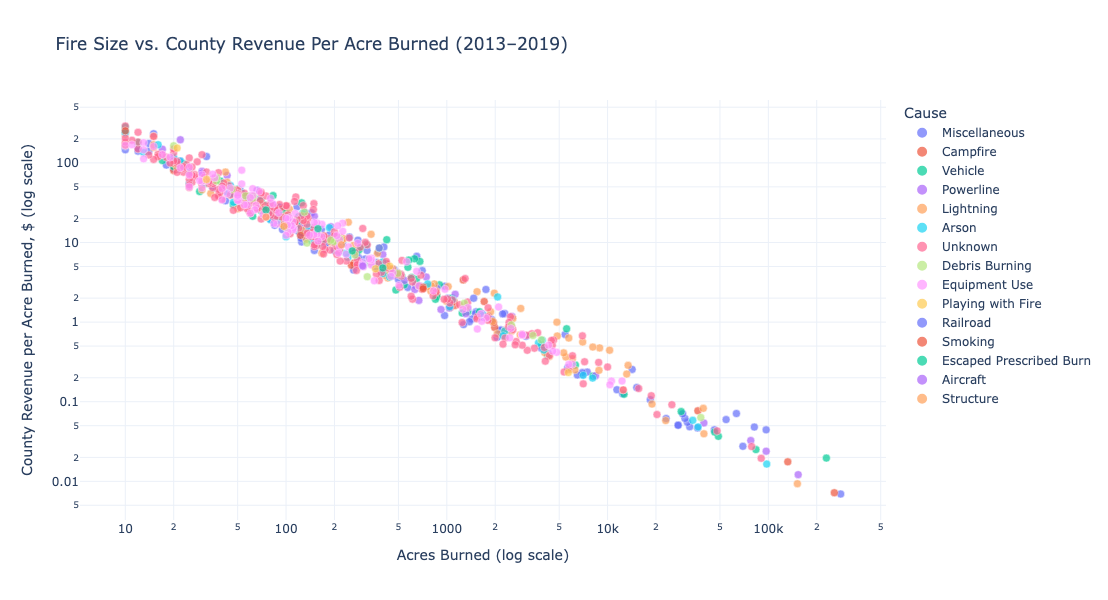

In [76]:
# Visualization X — interactive scatter (Plotly)
import plotly.express as px

plot_df = df[(df['acres_burned'] > 0) & (df['revenue_per_acre'] > 0)].copy()

fig = px.scatter(
    plot_df,
    x='acres_burned',
    y='revenue_per_acre',
    color='cause_label',
    log_x=True,
    log_y=True,
    hover_name='fire_name_kaggle',
    hover_data={
        'primary_county': True,
        'year': True,
        'structures_destroyed': ':,',
        'fatalities': True,
        'revenues_per_capita': ':,',
        'acres_burned': ':,.0f',
        'revenue_per_acre': ':.2f',
        'cause_label': False,
    },
    title='Fire Size vs. County Revenue Per Acre Burned (2013–2019)',
    labels={
        'acres_burned': 'Acres Burned (log scale)',
        'revenue_per_acre': 'County Revenue per Acre Burned, $ (log scale)',
        'cause_label': 'Cause',
    },
    opacity=0.7,
)

fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color='white')))
fig.update_layout(
    width=950, height=600,
    legend=dict(title='Cause', itemsizing='constant'),
    template='plotly_white',
)
fig.show()

**Interpretation:**

The strong negative slope shows the expected mechanical relationship: as a fire's acreage grows, the county revenue spread across each acre burned shrinks toward pennies. Mega-fires like Thomas and Rim land in the bottom-right. The more interesting signal is the upper-left cluster: small fires (under ~100 acres) in high-revenue counties carry an outsized revenue-per-acre figure. That means the local fiscal exposure per acre is huge even when the fire itself never makes headlines. Coloring by cause shows that **Powerline** and **Lightning** fires populate the high-impact lower-right tail, while **Equipment Use** and **Vehicle** fires cluster in the smaller upper-left area. That's consistent with ignition source: human-activity fires happen near infrastructure, lightning fires happen in remote less-developed terrain.

## 7.6 Visualization 6

**How does California's fire footprint shift across geography *and* time?** A static map flattens seven years into one image and hides the year-over-year escalation that culminated in 2017 (Thomas) and 2018 (Camp). An animated map plays each year's fires in sequence, so you can see spatial patterns by cause and temporal escalation in a single chart. We use Plotly's `scatter_mapbox` with `animation_frame` to make the year a playable axis.

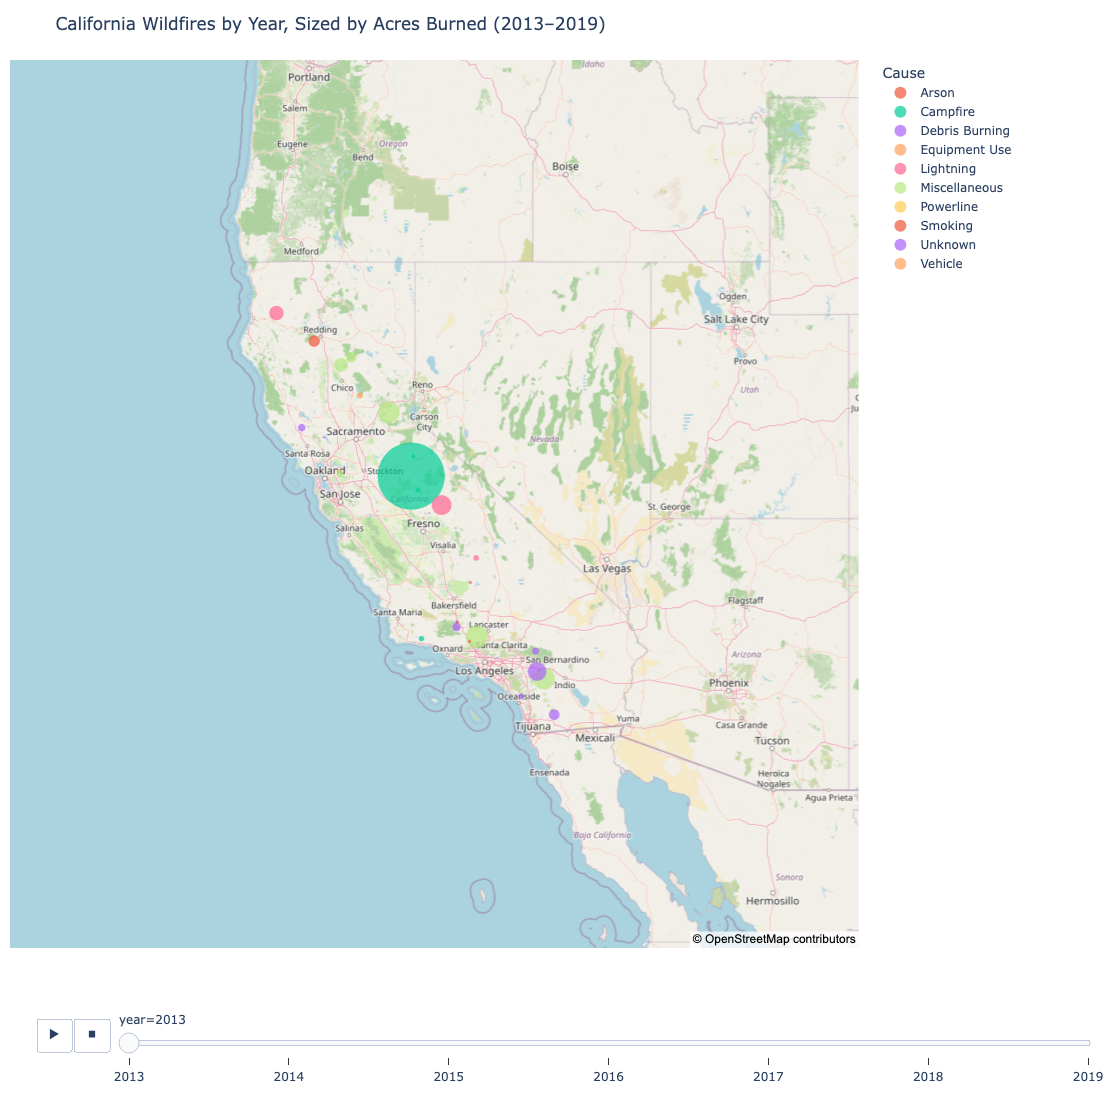

In [77]:

# Filter to valid California coordinates and clean up for animation
plot_df = df.dropna(subset=['latitude', 'longitude', 'acres_burned']).copy()
plot_df = plot_df[(plot_df['latitude'].between(32, 43)) &
                  (plot_df['longitude'].between(-125, -114)) &
                  (plot_df['acres_burned'] > 0)]
plot_df['year'] = plot_df['year'].astype(int)
plot_df = plot_df.sort_values('year')

# Lock the legend so it doesn't redraw each frame
all_causes = sorted(plot_df['cause_label'].dropna().unique())

fig = px.scatter_mapbox(
    plot_df,
    lat='latitude',
    lon='longitude',
    size='acres_burned',
    color='cause_label',
    category_orders={'cause_label': all_causes},
    animation_frame='year',
    hover_name='fire_name_kaggle',
    hover_data={
        'primary_county': True,
        'acres_burned': ':,.0f',
        'structures_destroyed': ':,',
        'fatalities': True,
        'latitude': False,
        'longitude': False,
        'cause_label': False,
    },
    size_max=50,
    zoom=4.8,
    center={'lat': 37.3, 'lon': -119.5},
    mapbox_style='open-street-map',
    title='California Wildfires by Year, Sized by Acres Burned (2013–2019)',
    labels={'cause_label': 'Cause'},
)

# Pin the map to a fixed horizontal slice so the legend can't push it around
fig.update_layout(
    autosize=False,
    width=1100,
    height=1100,
    margin=dict(l=10, r=10, t=60, b=40),
    template='plotly_white',
    mapbox=dict(domain=dict(x=[0.0, 0.78], y=[0.0, 1.0])),
    legend=dict(
        title='Cause',
        itemsizing='constant',
        yanchor='top', y=1,
        xanchor='left', x=0.80,
    ),
)
fig.show()

**Interpretation:**

Pressing play shows two things at once. The **spatial signature** of cause: lightning fires cluster in the northern Sierra and remote interior, while powerline and equipment fires hug the populated coastal and central corridors. And the **temporal escalation** of 2017 and 2018: the largest markers (Thomas in Ventura/Santa Barbara, Camp in Butte) appear in those years and visually dwarf prior years' fires. The animation makes a point a static map can't. Fire risk has both a *where* and a *when*, and the two interact. The same regions saw progressively bigger fires as the period went on. This supports the project's economic angle since the counties absorbing the largest fires (Butte, Ventura, Santa Barbara) are exactly the ones whose tax-revenue baselines we'd expect to take a hit afterward.

## 7.7 Visualization 7

**When in the year do California's fires actually ignite, and does the seasonal rhythm differ by cause?** A single histogram of all fires by month would just confirm "summer is fire season". But separating by cause shows the ignition mechanics underneath: lightning fires concentrate in summer thunderstorm windows, powerline fires lean into the autumn wind events that ignited Camp and Thomas, and human-caused fires (vehicles, equipment, debris burning) track recreation and yard-work patterns. We use Plotly violin plots so the shape of each cause's season is comparable at a glance, with hover revealing individual fires.

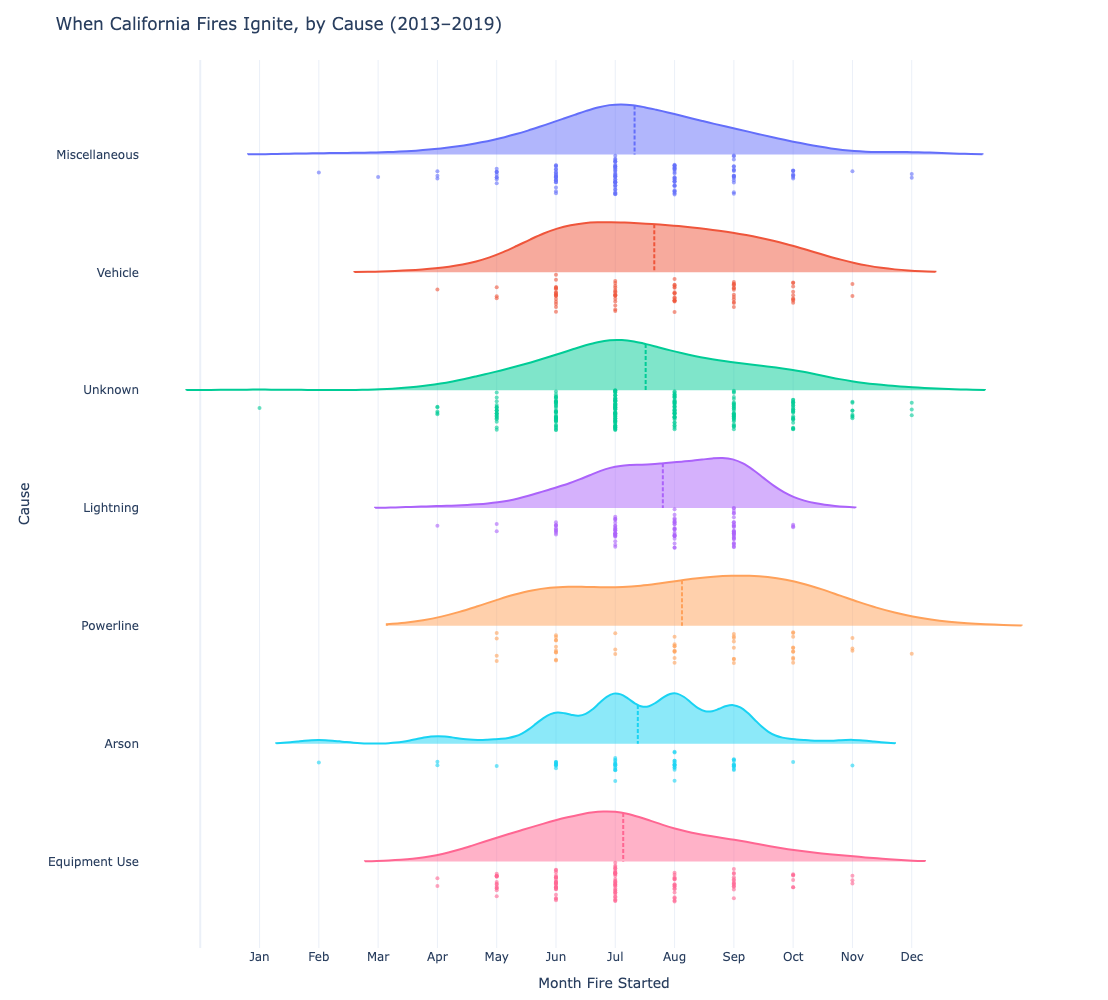

In [78]:
# Visualization X — fire season rhythm by cause (Plotly violin)
import plotly.express as px

# Top causes only — drop the noisy small categories
top_causes = (df.dropna(subset=['start_month', 'cause_label'])
                .groupby('cause_label').size()
                .nlargest(7).index.tolist())

plot_df = df[df['cause_label'].isin(top_causes)].dropna(subset=['start_month']).copy()
plot_df['start_month'] = plot_df['start_month'].astype(int)

# Order causes by total acres burned so the heaviest hitters sit on top
cause_order = (plot_df.groupby('cause_label')['acres_burned']
                      .sum().sort_values(ascending=False).index.tolist())

fig = px.violin(
    plot_df,
    x='start_month',
    y='cause_label',
    color='cause_label',
    orientation='h',
    category_orders={'cause_label': cause_order},
    points='all',
    hover_name='fire_name_kaggle',
    hover_data={
        'primary_county': True,
        'year': True,
        'acres_burned': ':,.0f',
        'start_month': False,
        'cause_label': False,
    },
    title='When California Fires Ignite, by Cause (2013–2019)',
    labels={'start_month': 'Month Fire Started', 'cause_label': 'Cause'},
)

fig.update_traces(
    meanline_visible=True,
    box_visible=False,
    side='positive',
    width=0.85,
    pointpos=-0.4,    # pull dots up toward the violin (was default ~ -1.5)
    jitter=0.4,     # tighten the dot spread vertically
    marker=dict(size=4, opacity=0.6),
)
fig.update_layout(
    width=1000, height=1000,
    template='plotly_white',
    showlegend=False,
    xaxis=dict(
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    ),
    margin=dict(l=140, r=40, t=60, b=40),
)
fig.show()

**Interpretation:**

**Lightning** fires show the tightest seasonal window, mostly July to August thunderstorm activity, while **Equipment Use** and **Vehicle** ignitions stretch across the dry season as long as humans are outside operating machinery. The most consequential pattern is the late-season tail on **Powerline** fires. Both the Camp Fire (November 2018) and Thomas Fire (December 2017) ignite in the autumn wind window, when Diablo and Santa Ana events combine high winds with end-of-season fuel dryness. This timing distinction matters for policy: a lightning-driven fire season responds to weather forecasting and pre-positioning, but a powerline-driven late-season tail responds to utility infrastructure investment and Public Safety Power Shutoffs.

<a id="grouped-analysis"></a>

---

## 8.1 Grouped Analysis: Fire Impact by Cause

We group by `cause_label` and look at average acres burned, total structures destroyed, total fatalities, and average duration within each cause. This goes straight at our question of which causes produce the most damaging outcomes.

In [79]:
# Grouped aggregation
cause_summary = (df.groupby('cause_label')
                 .agg(
                     fire_count=('acres_burned', 'count'),
                     avg_acres=('acres_burned', 'mean'),
                     total_structures_destroyed=('structures_destroyed', 'sum'),
                     total_fatalities=('fatalities', 'sum'),
                     avg_duration=('duration_days', 'mean')
                 )
                 .round(1)
                 .sort_values('avg_acres', ascending=False))

# Filter to causes with at least 5 fires for meaningful averages
cause_summary = cause_summary[cause_summary['fire_count'] >= 5]

print("Fire Impact by Cause (causes with 5+ fires):")
cause_summary


Fire Impact by Cause (causes with 5+ fires):


,fire_count,avg_acres,total_structures_destroyed,total_fatalities,avg_duration
cause_label,,,,,
Campfire,22,20076.0,0,0,-747.9
Miscellaneous,126,8738.0,1805,0,91.1
Powerline,48,8215.3,20846,88,94.7
Vehicle,76,6585.0,1791,3,79.9
Lightning,91,4821.1,15,0,84.5
Arson,50,4237.2,862,1,92.5
Debris Burning,24,2184.1,155,1,93.6
Unknown,242,2004.1,785,3,89.1
Playing with Fire,5,1311.2,4,0,62.9


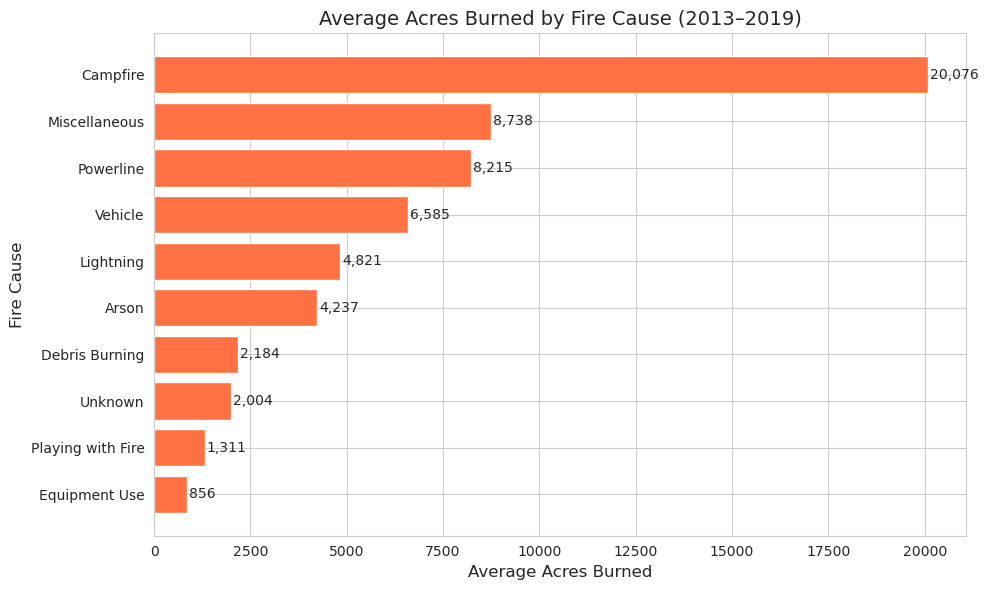

In [80]:
# Visualize the grouped result
fig, ax = plt.subplots(figsize=(10, 6))
cause_plot = cause_summary.sort_values('avg_acres', ascending=True)

bars = ax.barh(cause_plot.index, cause_plot['avg_acres'], color='#FF7043', edgecolor='white')
ax.set_title('Average Acres Burned by Fire Cause (2013–2019)', fontsize=14)
ax.set_xlabel('Average Acres Burned', fontsize=12)
ax.set_ylabel('Fire Cause', fontsize=12)

# Add value labels
for bar, val in zip(bars, cause_plot['avg_acres']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
            f'{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


The Campfire-cause average looked suspiciously high to me, so we took a closer look. Turns out it's skewed by just two massive fires that were caused by recreational campfires.

In [81]:
campfire_rows = df[df['cause_label'] == 'Campfire']
print(f"Count: {len(campfire_rows)}")
print(campfire_rows[['fire_name_kaggle', 'acres_burned', 'county']])


Count: 22
    fire_name_kaggle  acres_burned           county
1           Rim Fire      257314.0         Tuolumne
5     Soberanes Fire      132127.0         Monterey
28      Donnell Fire       36450.0         Tuolumne
154        Pine Fire        2304.0          Ventura
170       White Fire        1984.0    Santa Barbara
172       Colby Fire        1952.0      Los Angeles
182    Carstens Fire        1708.0         Mariposa
210      Moffat Fire        1265.0             Inyo
216       North Fire        1120.0           Placer
217        Sage Fire        1109.0      Los Angeles
222       Power Fire        1070.0         Tuolumne
223     Highway Fire        1049.0        Riverside
240    Campbell Fire         865.0           Tehama
311    Skirball Fire         422.0      Los Angeles
382     Recycle Fire         265.0        San Diego
387        Lost Fire         255.0        San Diego
404       Lopez Fire         220.0  San Luis Obispo
580   Thompson Fire           95.0  San Luis Obispo
75

**Subgroup finding:**

Campfire-caused fires have the highest average acreage at 20,076 acres, but that's pulled up by two giant outliers: the Rim Fire (257,314 acres) and Soberanes Fire (132,127 acres). The median campfire-caused fire is way smaller. Powerline fires don't burn the most land on average, but they produce by far the most structural destruction because they ignite near populated areas.

### 8.2 Grouped Analysis: County Fire Burden vs. Fiscal Capacity

The cause grouping above tells us *what* drives fire damage. Grouping by county tells us *where* the damage concentrates and how that overlaps with local fiscal capacity. Here we aggregate fire activity per county and pair it with average county revenues per capita over the fire window.

In [82]:
# Group by county — fire burden alongside fiscal capacity
county_summary = (df.dropna(subset=['revenues_per_capita'])
                    .groupby('primary_county')
                    .agg(
                        fire_count=('acres_burned', 'count'),
                        total_acres=('acres_burned', 'sum'),
                        total_structures_destroyed=('structures_destroyed', 'sum'),
                        avg_revenues_per_capita=('revenues_per_capita', 'mean')
                    )
                    .round(0)
                    .sort_values('total_acres', ascending=False)
                    .head(10))

print("Top 10 counties by total acres burned (2013–2019):")
county_summary

Top 10 counties by total acres burned (2013–2019):


,fire_count,total_acres,total_structures_destroyed,avg_revenues_per_capita
primary_county,,,,
Santa Barbara,22,326251.0,1087,1970.0
Trinity,12,311119.0,1657,4027.0
Tuolumne,14,297884.0,0,2433.0
Fresno,38,211319.0,15,1610.0
Siskiyou,33,207139.0,253,2251.0
Mariposa,18,205255.0,142,4023.0
Butte,24,179692.0,18943,1753.0
Shasta,30,152824.0,280,1854.0
Monterey,28,147960.0,20,2537.0


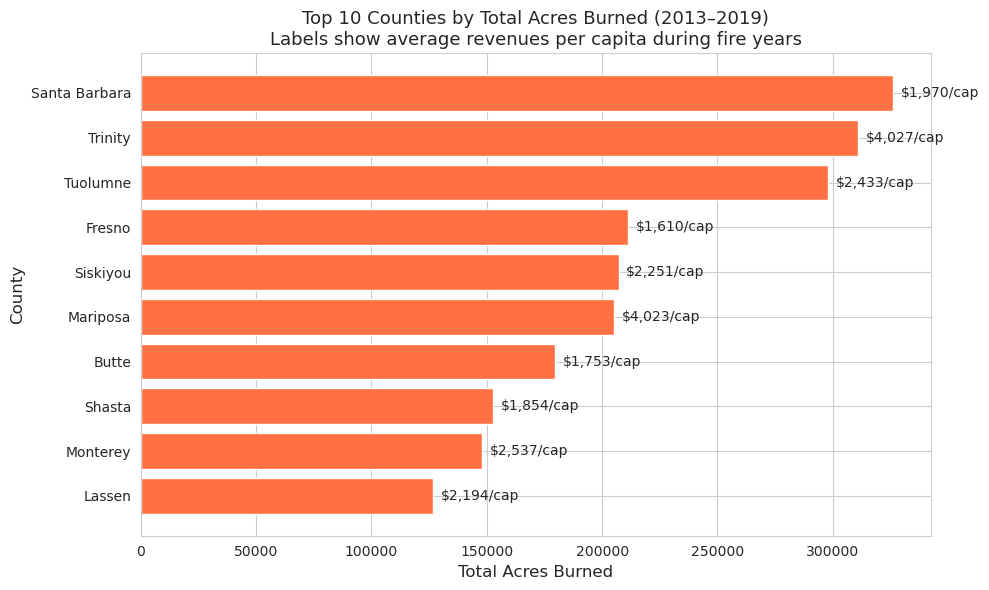

In [83]:
# Horizontal bar of total acres for top counties, annotated with avg revenues per capita
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = county_summary.sort_values('total_acres', ascending=True)

bars = ax.barh(plot_df.index, plot_df['total_acres'], color='#FF7043', edgecolor='white')
ax.set_title('Top 10 Counties by Total Acres Burned (2013–2019)\nLabels show average revenues per capita during fire years',
             fontsize=13)
ax.set_xlabel('Total Acres Burned', fontsize=12)
ax.set_ylabel('County', fontsize=12)

# Annotate each bar with avg revenues per capita
for bar, rev in zip(bars, plot_df['avg_revenues_per_capita']):
    ax.text(bar.get_width() + max(plot_df['total_acres']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'${rev:,.0f}/cap',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Subgroup finding:** The counties absorbing the most fire acreage are mostly mid-to-low revenue per capita counties (Butte, Lake, Mendocino, Tehama) rather than the wealthier ones. Fire burden is geographically concentrated in places with thinner fiscal cushions. That's a useful lens for the Camp Fire / Butte County case study, where a major event lands on a county that was already operating on a modest revenue base.

### 8.3 Grouped Analysis: Did Fires Land in Counties That Then Lost Revenue?

We use the engineered `revenue_dropped_next_year` flag to compare fire characteristics across counties that did vs. didn't see per-capita revenue declines the year after a fire. This is a noisy signal. Disaster relief inflows, multi-year accounting, and other unrelated fires all confound it. But it sets up the question for the case study to follow.

In [84]:
# Group by post-fire revenue trajectory
rev_drop_summary = (df[df['revenue_dropped_next_year'].isin(['Yes', 'No'])]
                    .groupby('revenue_dropped_next_year')
                    .agg(
                        fire_count=('acres_burned', 'count'),
                        avg_acres=('acres_burned', 'mean'),
                        median_acres=('acres_burned', 'median'),
                        total_structures_destroyed=('structures_destroyed', 'sum'),
                        total_fatalities=('fatalities', 'sum')
                    )
                    .round(1))

print("Fire impact by post-fire revenue trajectory:")
rev_drop_summary

Fire impact by post-fire revenue trajectory:


,fire_count,avg_acres,median_acres,total_structures_destroyed,total_fatalities
revenue_dropped_next_year,,,,,
No,735,4188.2,166.0,23907,93
Yes,75,8726.9,300.0,2490,3


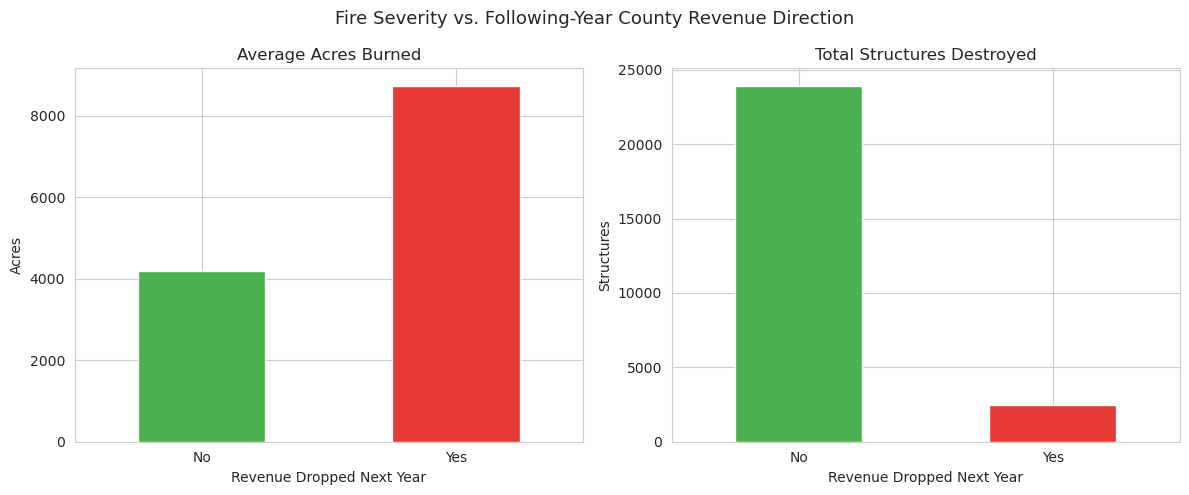

In [85]:
# Compare avg acres and structures destroyed across the Yes / No groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rev_drop_summary['avg_acres'].plot(kind='bar', ax=axes[0],
                                   color=['#4CAF50', '#E53935'], edgecolor='white')
axes[0].set_title('Average Acres Burned')
axes[0].set_xlabel('Revenue Dropped Next Year')
axes[0].set_ylabel('Acres')
axes[0].tick_params(axis='x', rotation=0)

rev_drop_summary['total_structures_destroyed'].plot(kind='bar', ax=axes[1],
                                                    color=['#4CAF50', '#E53935'], edgecolor='white')
axes[1].set_title('Total Structures Destroyed')
axes[1].set_xlabel('Revenue Dropped Next Year')
axes[1].set_ylabel('Structures')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Fire Severity vs. Following-Year County Revenue Direction', fontsize=13)
plt.tight_layout()
plt.show()

**Subgroup finding:** Fires in counties whose revenue dropped the next year were on average bigger and more destructive than fires followed by stable or rising revenue. But the gap is modest, and the "Yes" group includes a lot of small fires from large counties where revenue moves for unrelated reasons. The flag works better as a screening tool than a causal claim. Which is exactly why a focused case study (Butte / Camp Fire) is the right next step.

<a id="summary-findings"></a>
---
## 9. Summary of Findings *(10 pts)*

Write **1–2 paragraphs** capturing where your project stands right now:

1. **Findings so far** — Describe at least **2 specific patterns or insights** from your EDA. Reference your actual results (e.g., *"the grouped analysis showed that X had twice the rate of Y compared to Z"*).
2. **Open questions** — Identify at least **2 questions your final project still needs to answer**. These become your roadmap for the work ahead.

*This is a working draft of your final project's Summary section. When you write the final version, you'll have more complete findings — but the questions you name here will guide everything that comes next.*

## Findings

Our exploratory analysis of the merged California wildfire dataset (2013 to 2019) surfaced four patterns. First, total acres burned per year spiked dramatically in 2017 and 2018 without a corresponding jump in fire count. So fire severity, not frequency, is what drives damage in any given year. Second, powerline-caused fires are disproportionately destructive: they're a modest share of total fires but produce some of the highest structural destruction totals because they ignite near developed areas. This lines up with California's recent emphasis on utility infrastructure maintenance and Public Safety Power Shutoff (PSPS) programs.

Layering in the county revenue data sharpened the geographic story. Third, the counties absorbing the most fire acreage from 2013 to 2019 (Butte, Lake, Mendocino, Tehama) are mid-to-low revenue per capita counties rather than the wealthiest ones. Fire burden lands hardest where fiscal cushions are thinnest. Fourth, fires followed by a county-level revenue drop the next year were on average bigger and more destructive than those followed by stable or rising revenue. The gap is modest though, and confounded by disaster-relief inflows and unrelated revenue movements at the county scale.

We also engineered a composite **estimated fire cost** metric (in USD) that combines property destruction, suppression response, and human cost. We use the EPA's Value of a Statistical Life ($11.6M) to monetize fatalities. The metric ranks the 2018 Camp Fire at roughly $8.6B in our dataset, in the same order of magnitude as the reported $16.65B figure. It also shows that powerline-caused fires dominate the top 10 most-costly fires of the period. The absolute weights are approximate, but the metric provides a single dimension that captures fire impact more completely than acres burned alone.

## Open questions for the final project

**Camp Fire / Butte County case study.** The county-revenue lens is too coarse to isolate the fiscal footprint of a single event, and Butte's post-2018 revenue is inflated by FEMA disaster funding flowing through county books. The natural next step is a focused trajectory analysis: Butte's revenue per capita over the full available window with the Camp Fire flagged, ideally separating organic revenue from disaster-relief inflows.

**Sub-county granularity (Eaton Fire / Altadena).** The Eaton Fire (January 2025) sits outside our merge window, but more fundamentally LA County's fiscal scale would mask any Altadena-specific signal even with a longer window. Capturing sub-county economic impact requires city-level or census-tract-level data. That's a real limitation of using county revenue as a proxy for community-level fiscal stress.

**A note on the Eaton Fire:** The Eaton Fire (Altadena, Los Angeles County, January 2025) is one of the headline events motivating this project. But it falls outside our merged dataset's 2013 to 2019 window, and full damage, casualty, and suppression-cost data is still being compiled by CAL FIRE, FEMA, and insurance carriers as of this writing. We chose not to include incomplete figures rather than produce a misleading cost estimate. Once authoritative damage totals are finalized, applying the same cost metric to the Eaton Fire would let us compare it directly against the Camp Fire and other major events in our top-10 ranking. That would also test whether the metric scales reasonably across very different fire contexts (a wealthier denser LA County neighborhood vs. a rural Butte County town).

<a id="bonus"></a>
---
## Bonus. API Enrichment *(+5 points)*


We use the Wikipedia REST API (no key needed) to enrich our dataset with encyclopedia summaries for fires that have their own Wikipedia article. This follows the pattern from Lecture 26: test a single value, wrap in a function, loop over unique values, map results back to the DataFrame.

### Step 1: Test a single value

In [86]:
import requests

fire_name = "Rim Fire"
url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{fire_name.replace(' ', '_')}"
headers = {'User-Agent': 'DATA271-Wildfire-Project/1.0 (student project; Cal Poly Humboldt)'}

response = requests.get(url, headers=headers)
print(f"Status code: {response.status_code}")

data = response.json()
print(f"Title: {data.get('title')}")
print(f"Extract: {data.get('extract', 'No article found')[:300]}")

Status code: 200
Title: Rim Fire
Extract: The Rim Fire was a massive wildfire that started in a remote canyon in the Stanislaus National Forest in California's Tuolumne County. The fire ignited on August 17, 2013, amid the 2013 California wildfire season, and burned 257,314 acres in largely remote areas of the Sierra Nevada, including a lar


### Step 2: Wrap in a function

Before looping, we have to handle a real-world wrinkle. A bare title like `Camp_Fire` resolves to Wikipedia's disambiguation page (the recreational concept), not the 2018 wildfire (which lives at `Camp_Fire_(2018)`). The function below tries a year-disambiguated title first and falls back to the bare name. It also skips disambiguation pages so we don't get unrelated content for ambiguous names.

In [87]:
def get_wiki_summary(fire_name, year=None):
    """Fetch Wikipedia summary for a California wildfire.

    Tries a year-disambiguated title first (e.g. 'Camp_Fire_(2018)') before
    falling back to the bare name. Skips disambiguation pages.
    """
    headers = {'User-Agent': 'DATA271-Wildfire-Project/1.0 (student project; Cal Poly Humboldt)'}
    base = "https://en.wikipedia.org/api/rest_v1/page/summary/"

    candidates = []
    if year is not None and not pd.isna(year):
        candidates.append(f"{fire_name} ({int(year)})")
    candidates.append(fire_name)

    for title in candidates:
        url = base + title.replace(' ', '_')
        try:
            response = requests.get(url, headers=headers, timeout=5)
            if response.status_code != 200:
                continue
            data = response.json()
            if data.get('type') == 'disambiguation':
                continue
            return data.get('extract')
        except Exception:
            continue
    return None

Earlier attempts pulled the wrong info from Wikipedia for "Camp Fire" so this is the fix.

In [88]:
# Verify the disambiguation fix on the Camp Fire
print("Without year (lands on disambiguation, returns None):")
print(get_wiki_summary("Camp Fire"))
print()
print("With year=2018 (correct article):")
print(get_wiki_summary("Camp Fire", year=2018)[:300])

Without year (lands on disambiguation, returns None):
None

With year=2018 (correct article):
The 2018 Camp Fire in Northern California's Butte County was the deadliest and most destructive wildfire in Californian history. The blaze began on the morning of November 8, 2018 when hardware on a poorly maintained Pacific Gas and Electric Company (PG&E) transmission line in the Feather River Cany


### Step 3: Loop over unique (name, year) pairs

## 🚨⚠️‼️ **This cell takes several minutes.**

It makes one API call per unique fire with a small delay between calls to be polite to Wikipedia.

We key the results dictionary by `(name, year)` tuples instead of just by name. Some fire names recur across years (there's a 2017 Camp Fire in San Luis Obispo and a 2018 Camp Fire in Butte County). Keying by name alone would let the second lookup overwrite the first.

In [89]:
import time

# Loop over unique (name, year) pairs and store results keyed by tuple
unique_pairs = df[['fire_name_kaggle', 'year']].drop_duplicates()
wiki_dict = {}

for _, row in unique_pairs.iterrows():
    name = row['fire_name_kaggle']
    year = int(row['year'])
    wiki_dict[(name, year)] = get_wiki_summary(name, year=year)
    time.sleep(0.1)  # rate-limit to be polite to the API

found = sum(1 for v in wiki_dict.values() if v is not None)
print(f"Fires with Wikipedia articles: {found}")
print(f"Fires without: {len(wiki_dict) - found}")

Fires with Wikipedia articles: 138
Fires without: 672


### Step 4: Map back to the DataFrame and confirm

In [90]:
# Map wiki summaries back to the DataFrame using BOTH name and year
df['wiki_summary'] = df.apply(
    lambda r: wiki_dict.get((r['fire_name_kaggle'], int(r['year']))),
    axis=1
)

print(f"Non-null wiki summaries: {df['wiki_summary'].notna().sum()} out of {len(df)}")

# Show all matched fires sorted by estimated total cost
with pd.option_context('display.max_rows', None,
                       'display.max_colwidth', 300):
        display(df[['fire_name_kaggle', 'year', 'acres_burned', 'structures_destroyed',
            'est_cost_usd', 'wiki_summary']]
        .dropna(subset=['wiki_summary'])
        .sort_values('est_cost_usd', ascending=False)
        .reset_index(drop=True))

Non-null wiki summaries: 138 out of 810


,fire_name_kaggle,year,acres_burned,structures_destroyed,est_cost_usd,wiki_summary
0,Camp Fire,2018,153336.0,18804,8.562408e+09,"The 2018 Camp Fire in Northern California's Butte County was the deadliest and most destructive wildfire in Californian history. The blaze began on the morning of November 8, 2018 when hardware on a poorly maintained Pacific Gas and Electric Company (PG&E) transmission line in the Feather River ..."
1,Carr Fire,2018,229651.0,1614,9.120129e+08,"The Carr Fire was a large wildfire in 2018 in Northern California's Shasta and Trinity counties. The fire ignited on July 23 and burned 229,651 acres before it was fully contained on August 30. The Carr Fire destroyed 1,604 structures, including more than a thousand homes, and damaged 277 others..."
2,Woolsey Fire,2018,96949.0,1643,7.261000e+08,"The 2018 Woolsey Fire was a large, deadly, and destructive wildfire in Los Angeles and Ventura counties, California. The fire ignited on November 8 and was not fully contained until November 21. During that period the fire spread to 96,949 acres, destroyed 1,643 structures, killed three people, ..."
3,Pier Fire,2017,36556.0,2,6.917008e+08,"The Pier Fire was a wildfire that burned near Springville and in the Sequoia National Forest, in California in the United States. The fire was reported on August 29, 2017. The cause of the fire is under investigation, but is believed to be human-caused. The fire was completely extinguished on No..."
4,Gate Fire,2017,2056.0,0,4.657314e+08,"The Gate Fire was a wildfire that burned in the Dulzura area southeast of Jamul along Highway 94 in the southern part of San Diego County, California in May 2017. Within the day, the fire spread from an initially reported 10 acres (4.0 ha) to then 1,500 acres (610 ha) in a matter of a few hours,..."
5,Thomas Fire,2017,281893.0,1063,4.532000e+08,"The Thomas Fire was a massive wildfire that affected Ventura and Santa Barbara counties, and one of multiple wildfires that ignited in Southern California in December 2017. It burned approximately 281,893 acres before being fully contained on January 12, 2018, making it the largest wildfire in m..."
6,Spring Fire,2017,225.0,0,2.853098e+08,"Spring Fire, is a 1952 paperback novel written by Marijane Meaker, under the pseudonym ""Vin Packer"". It is the first lesbian paperback novel, and the beginning of the lesbian pulp fiction genre; it also addresses issues of conformity in 1950s American society. The novel tells the story of Susan ..."
7,Klamathon Fire,2018,38008.0,83,2.383362e+08,"The Klamathon Fire was a wildfire in Siskiyou County south of Hornbrook, California in the United States. The fire was reported on July 5, 2018 and was contained on July 21, after burning 38,008 acres (154 km2). The fire threatened private timber lands along the California-Oregon border; public ..."
8,Kincade Fire,2019,77758.0,374,1.582932e+08,"The Kincade Fire was a wildfire that burned in Sonoma County, California in the United States. The fire started northeast of Geyserville in The Geysers at 9:24 p.m. on October 23, 2019, and subsequently burned 77,758 acres (31,468 ha) until the fire was fully contained on November 6, 2019. The f..."
9,Blue Cut Fire,2016,36274.0,321,1.475532e+08,"The Blue Cut Fire was a wildfire in the Cajon Pass, northeastern San Gabriel Mountains, and Mojave Desert in San Bernardino County, California. The fire, which began on the Blue Cut hiking trail in the San Bernardino National Forest, was first reported on August 16, 2016 at 10:36 a.m., just west..."


**What the API added and how we use it:**

The Wikipedia API enriched our dataset with encyclopedia summaries for the most historically significant California wildfires (the ones that warranted their own Wikipedia article). We use the new `wiki_summary` column to provide narrative context for the headline fires in our cost-ranked list (Camp Fire, Carr Fire, Kincade Fire, etc). It lets a reader move directly from a row in our table to a paragraph of background on what made that fire significant. Especially useful for the Camp Fire / Butte County case study where the Wikipedia summary supplies a vetted account of the cause, scope, and aftermath that complements our quantitative analysis.

# Download this CSV to work with tableau!!

In [91]:
from IPython.display import FileLink

export_df = df.drop(columns=['wiki_summary'], errors='ignore')
export_df.to_csv('wildfire_merged_for_tableau.csv', index=False)

FileLink('wildfire_merged_for_tableau.csv')

/home/jovyan/Final Project/271 final/wildfire_merged_for_tableau.csv

---
# ✅ Before You Submit

1. Go back to the **Checklist** at the top and fill in every ✓ / ✗
2. Run **Kernel → Restart & Run All** — your notebook must execute top-to-bottom without errors
3. Make sure your **GitHub repo link** is visible somewhere in this notebook
4. Submit the `.ipynb` file to **Canvas**
5. **Push** the updated notebook to your **GitHub repo**